<div style="width:90%;background-color:#cfe8c9;border:5px solid #3e2723;border-radius:16px;padding:20px 0;text-align:center;font-family:Arial,sans-serif;">
  <span style="font-size:36px;color:#1b5e20;">🌱</span>
  <span style="font-size:32px;font-weight:800;color:#000000;letter-spacing:1px;"> Ugaoo — Exploratory Data Analysis</span>
</div>

### Table of Contents
1. [Introduction](#1-introduction)
2. [About Dataset & Problem](#2-about-dataset--problem)
3. [Importing Libraries](#3-importing-libraries)
4. [Data Loading & Merging](#4-data-loading--merging)
5. [Data Cleaning](#5-data-cleaning)
6. [Exploratory Data Analysis](#6-exploratory-data-analysis)
   - 6.1 Univariate Analysis
   - 6.2 Bivariate Analysis
   - 6.3 City × Channel Analysis
7. [Key Insights](#7-key-insights)
8. [Business Recommendations](#8-business-recommendations)


<div style="display:inline-block;background-color:#e8f2ff;border-radius:9999px;padding:8px 20px;font-size:20px;font-weight:700;color:#111;">1. Introduction</div>

<div style="background:#f4faf5;border-left:6px solid #2e7d32;padding:20px;border-radius:8px;color:#000;">

**Ugaoo** is one of India's leading online gardening and plant e-commerce platforms, offering live plants, seeds, gardening tools, and accessories.

This notebook is an exploratory data analysis of Ugaoo's e-commerce operations using a **5-table dataset** (orders, customers, products, city-channel sales, and employees). The goal is to uncover actionable patterns that support decisions across:

- **Revenue & profitability** — which categories, cities, and channels generate the most value
- **Customer behaviour** — segment performance, repeat buying patterns
- **Delivery & operations** — delivery speed and return patterns
- **Discount effectiveness** — where discounting helps vs. where it erodes margin
- **Channel strategy** — how sales channels perform across metro and non-metro cities

</div>

<div style="display:inline-block;background-color:#e8f2ff;border-radius:9999px;padding:8px 20px;font-size:20px;font-weight:700;color:#111;">1. About Dataset & Problem</div>

<div style="background:#f4f7ff;border-left:6px solid #3b6cff;padding:20px;border-radius:8px;color:#000;line-height:1.6;">

### Dataset Overview

| File | Rows | Cols | Used For |
|------|------|------|-----------|
| ugaoo_orders.csv | 50,000 | 24 | Core fact table — all revenue, delivery, and return analysis |
| ugaoo_customers.csv | 12,000 | 15 | Customer demographics, segment, NPS, acquisition channel |
| ugaoo_products.csv | 52 | 22 | Product cost, margin %, category, price tier |
| ugaoo_city_channel_sales.csv | 4,032 | 16 | City × channel revenue analysis (Section 6.3) — exported for Power BI |
| ugaoo_employees.csv | 600 | 18 | Loaded for completeness; HR analysis out of scope for this EDA |

**Central question:** Where is Ugaoo growing, where is profitability at risk, and what operational levers can improve customer experience and margin?
</div>

<div style="display:inline-block;background-color:#e8f2ff;border-radius:9999px;padding:8px 20px;font-size:20px;font-weight:700;color:#111;">3. Importing Libraries</div>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})

UGAOO_GREEN = ['#1b5e20','#2e7d32','#388e3c','#43a047','#4caf50',
               '#66bb6a','#81c784','#a5d6a7','#c8e6c9','#e8f5e9']
UGAOO_BROWN = '#6d4c41'
BG_COLOR    = '#f6fbf6'

print("Libraries loaded ✅")

Libraries loaded ✅


<div style="display:inline-block;background-color:#e8f2ff;border-radius:9999px;padding:8px 20px;font-size:20px;font-weight:700;color:#111;">4. Data Loading & Merging</div>

<div style="background:#eef9ff;border-left:6px solid #17a2b8;padding:16px;border-radius:6px;color:#000;">

**Merging strategy:**
`orders` is the central fact table — it holds every transaction and is the base for all revenue, delivery, and return analysis. Customer and product tables are joined to it so every row carries the full context needed for segmentation and margin analysis. The resulting DataFrame `df` mirrors what a single enriched fact table would look like in a warehouse, making EDA and Power BI export straightforward.

City-channel sales, inventory, and employees are kept as separate tables and used independently for their respective analyses.
</div>

In [2]:
import os
os.getcwd()

'c:\\Users\\Asus\\OneDrive\\Desktop\\Ugao_project'

In [3]:
import os
os.chdir(r'C:\Users\Asus\OneDrive\Desktop\Ugao_project')

In [4]:
# Load all 6 source files
orders    = pd.read_csv('ugaoo_orders.csv', parse_dates=['order_date'])
customers = pd.read_csv('ugaoo_customers.csv', parse_dates=['join_date'])
products  = pd.read_csv('ugaoo_products.csv')
city_ch   = pd.read_csv('ugaoo_city_channel_sales.csv')
inventory = pd.read_csv('ugaoo_inventory.csv')
employees = pd.read_csv('ugaoo_employees.csv')

print("Files loaded:")
for name, frame in [("orders",orders),("customers",customers),("products",products),
                    ("city_ch",city_ch),("inventory",inventory),("employees",employees)]:
    print(f"  {name:<12} → {frame.shape}")

Files loaded:
  orders       → (50000, 24)
  customers    → (12000, 15)
  products     → (52, 22)
  city_ch      → (4032, 16)
  inventory    → (1872, 19)
  employees    → (600, 18)


In [5]:
# Step 1: orders + customer demographics (left join — keep all orders)
df = orders.merge(
    customers[['customer_id','gender','age','segment','acquisition_channel','nps_score','app_user']],
    on='customer_id', how='left'
)

# Step 2: + product cost and margin info
df = df.merge(
    products[['product_id','cost_price_inr','gross_margin_pct','maintenance_level','is_bestseller']],
    on='product_id', how='left'
)

print(f"Merged DataFrame shape: {df.shape}")
df.head(5)

Merged DataFrame shape: (50000, 34)


,order_id,customer_id,order_date,order_month,order_quarter,channel,city,state,product_id,product_name,...,gender,age,segment,acquisition_channel,nps_score,app_user,cost_price_inr,gross_margin_pct,maintenance_level,is_bestseller
0,UGA2300001,CUST007303,2024-04-10,Apr-2024,Q2 FY25,Flipkart,Kolkata,West Bengal,PL013,Bougainvillea,...,Female,28,Loyal,Organic Search,7,Yes,115,67.0,Low,No
1,UGA2300002,CUST007640,2024-06-04,Jun-2024,Q2 FY25,Meesho,Mumbai,Maharashtra,PL006,ZZ Plant,...,Male,35,New,Amazon,5,Yes,160,67.9,Very Low,No
2,UGA2300003,CUST003383,2024-04-09,Apr-2024,Q2 FY25,Retail Store,Ahmedabad,Gujarat,PT007,Vertical Wall Planter (5 pocket),...,Female,21,Returning,Instagram,9,Yes,390,67.5,NaN,No
3,UGA2300004,CUST008444,2023-09-26,Sep-2023,Q3 FY24,Retail Store,Mumbai,Maharashtra,TL002,Watering Can 2L,...,Female,25,New,Organic Search,10,Yes,95,68.2,NaN,No
4,UGA2300005,CUST007171,2024-08-24,Aug-2024,Q3 FY25,Flipkart,Noida,Uttar Pradesh,SD003,Coriander Seeds (50g),...,Female,21,Loyal,Google Ads,8,No,12,79.7,Low,No


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 34 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   order_id               50000 non-null  str           
 1   customer_id            50000 non-null  str           
 2   order_date             50000 non-null  datetime64[us]
 3   order_month            50000 non-null  str           
 4   order_quarter          50000 non-null  str           
 5   channel                50000 non-null  str           
 6   city                   50000 non-null  str           
 7   state                  50000 non-null  str           
 8   product_id             50000 non-null  str           
 9   product_name           50000 non-null  str           
 10  category               50000 non-null  str           
 11  sub_category           50000 non-null  str           
 12  quantity               50000 non-null  int64         
 13  unit_price_i

In [7]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
order_date,50000,2024-03-31 00:42:35.711999,2023-04-01 00:00:00,2023-10-02 00:00:00,2024-03-31 00:00:00,2024-10-01 00:00:00,2025-03-30 00:00:00,NaN
quantity,50000.0,1.73658,1.0,1.0,1.0,2.0,4.0,0.962169
unit_price_inr,50000.0,465.74,49.0,199.0,299.0,549.0,2749.0,468.186873
discount_pct,50000.0,7.7981,0.0,0.0,5.0,15.0,25.0,7.563483
gross_value_inr,50000.0,809.49182,49.0,249.0,498.0,899.0,10996.0,1033.553292
final_order_value_inr,50000.0,857.80968,37.0,262.0,552.0,1103.0,20342.0,1026.647042
shipping_days,50000.0,2.4617,0.0,2.0,2.0,3.0,7.0,1.596879
delivery_rating,43906.0,3.996447,3.0,3.0,4.0,5.0,5.0,0.81727
age,50000.0,33.98764,21.0,28.0,34.0,40.0,62.0,8.429721
nps_score,50000.0,7.8087,5.0,7.0,8.0,9.0,10.0,1.544588


In [8]:
df.sample(5)

,order_id,customer_id,order_date,order_month,order_quarter,channel,city,state,product_id,product_name,...,gender,age,segment,acquisition_channel,nps_score,app_user,cost_price_inr,gross_margin_pct,maintenance_level,is_bestseller
25212,UGA2325213,CUST002596,2023-08-30,Aug-2023,Q3 FY24,Corporate Gifting,Delhi,Delhi,TL004,Pebbles Decorative 500g,...,Male,25,Returning,Instagram,8,No,55,69.3,NaN,No
4000,UGA2304001,CUST010226,2023-07-19,Jul-2023,Q3 FY24,Flipkart,Mumbai,Maharashtra,TL003,Premium Potting Mix 5kg,...,Female,32,Loyal,Word of Mouth,9,No,130,67.4,NaN,No
42417,UGA2342418,CUST007989,2025-02-28,Feb-2025,Q1 FY25,Corporate Gifting,Mumbai,Maharashtra,PT007,Vertical Wall Planter (5 pocket),...,Female,23,Returning,Email,6,Yes,390,67.5,NaN,No
33357,UGA2333358,CUST006084,2024-02-15,Feb-2024,Q1 FY24,Blinkit,Mumbai,Maharashtra,PL020,Bamboo Palm,...,Female,21,New,Organic Search,8,Yes,270,66.2,Low,No
1756,UGA2301757,CUST005129,2025-02-25,Feb-2025,Q1 FY25,Retail Store,Bengaluru,Karnataka,FR003,Seaweed Liquid Fertiliser,...,Female,33,Loyal,Amazon,9,Yes,80,67.9,NaN,No


<div style="display:inline-block;background-color:#e8f2ff;border-radius:9999px;padding:8px 20px;font-size:20px;font-weight:700;color:#111;">5. Data Cleaning</div>

In [9]:
# Check for duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [10]:
# Summary of columns with missing values
def missing_info(df):
    result = pd.DataFrame({
        'column': df.columns,
        'missing_count': df.isnull().sum().values,
        'missing_pct': np.round(df.isnull().mean() * 100, 2).values
    })
    return (result[result['missing_count'] > 0]
            .sort_values('missing_count', ascending=False)
            .reset_index(drop=True))

missing_info(df)

,column,missing_count,missing_pct
0,maintenance_level,22107,44.21
1,delivery_rating,6094,12.19


**Handling `maintenance_level` nulls:**
Products that are not plants (e.g., tools, pots, accessories) logically have no maintenance level. Before imputing, we check whether nulls are confined to specific categories.

In [11]:
# Inspect whether maintenance_level nulls are category-specific
print(df[df['maintenance_level'].isna()]['category'].value_counts())

# If nulls belong to non-plant categories, fill with 'Not Applicable'
# rather than using an arbitrary value like 'Unknown'
df['maintenance_level'] = df['maintenance_level'].fillna('Not Applicable')
print("\nmaintenance_level nulls remaining:", df['maintenance_level'].isna().sum())

category
Pots & Planters    7647
Gifting            4905
Fertilisers        4806
Tools              4749
Name: count, dtype: int64

maintenance_level nulls remaining: 0


**Handling `delivery_rating` nulls:**
A null delivery rating means the customer chose not to rate the delivery — it is not missing data but an absence of feedback. We label it `'No Rating'` so it is explicit in visualisations and does not get dropped silently.

In [12]:
# Customers who did not submit a rating → label explicitly
df['delivery_rating'] = df['delivery_rating'].fillna('No Rating')
print("delivery_rating nulls after fix:", df['delivery_rating'].isna().sum())

delivery_rating nulls after fix: 0


<div style="display:inline-block;background-color:#e8f2ff;border-radius:9999px;padding:8px 20px;font-size:20px;font-weight:700;color:#111;">5. Feature Engineering</div>

In [13]:
# ── Derived financial columns ─────────────────────────────────
df['profit']        = (df['final_order_value_inr'] * df['gross_margin_pct'] / 100).round(2)
df['profit_margin'] = df['gross_margin_pct']           # alias for chart readability
df['final_price']   = (df['final_order_value_inr'] / df['quantity']).round(2)  # price per unit

# ── Return flag ────────────────────────────────────────────────
# replacement_claimed (Yes/No) is the source of truth for returns
df['is_returned'] = df['replacement_claimed']          # compatibility alias

# ── Time columns ───────────────────────────────────────────────
df['year']       = df['order_date'].dt.year
df['month']      = df['order_date'].dt.month
df['month_name'] = df['order_date'].dt.strftime('%b')
df['quarter']    = df['order_date'].dt.quarter

df['fy'] = df.apply(lambda r: f"{r['year']}-{str(r['year']+1)[-2:]}" if r['month'] >= 4 else f"{r['year']-1}-{str(r['year'])[-2:]}", axis=1)
# e.g. April 2023 → "2023-24", January 2023 → "2022-23"

# ── Column renames (to align with chart variable names used throughout) ───────
df.rename(columns={
    'final_order_value_inr': 'order_value',   # cleaner name for charts
    'shipping_days':         'delivery_days', # intuitive label
    'unit_price_inr':        'unit_price',    # drop unit suffix for brevity
    'payment_method':        'payment_mode',  # consistent with old EDA
}, inplace=True)

df['risk_flag'] = (df['discount_pct'] > 20) & (df['order_value'] > df['order_value'].median())

print("Feature engineering complete ✅")
print("Shape:", df.shape)
df[['order_value','profit','profit_margin','final_price','delivery_days','is_returned']].head(3)

Feature engineering complete ✅
Shape: (50000, 43)


,order_value,profit,profit_margin,final_price,delivery_days,is_returned
0,349,233.83,67.0,349.00,5,No
1,1896,1287.38,67.9,474.00,3,No
2,2698,1821.15,67.5,899.33,4,No


### Outlier Check

We check four key numeric columns for extreme values using the IQR method. First we plot the raw distributions so the outlier extent is visible, then we apply IQR clipping (Winsorization) to remove extreme tails that would distort averages and charts. No rows are deleted — only extreme values are capped.

In [14]:
# Detect outliers using IQR method on key numeric columns
def detect_outliers(data, cols):
    rows = []
    for col in cols:
        q1  = data[col].quantile(0.25)
        q3  = data[col].quantile(0.75)
        iqr = q3 - q1
        upper = q3 + 1.5 * iqr
        lower = q1 - 1.5 * iqr
        n_out = ((data[col] > upper) | (data[col] < lower)).sum()
        rows.append({
            'column':    col,
            'lower_bound': round(lower, 2),
            'upper_bound': round(upper, 2),
            'outlier_count': n_out,
            'outlier_pct':   round(n_out / len(data) * 100, 2)
        })
    return pd.DataFrame(rows)

detect_outliers(df, ['unit_price', 'order_value', 'profit', 'delivery_days'])

,column,lower_bound,upper_bound,outlier_count,outlier_pct
0,unit_price,-326.00,1074.00,4907,9.81
1,order_value,-999.50,2364.50,2832,5.66
2,profit,-648.14,1569.46,2559,5.12
3,delivery_days,0.50,4.50,12464,24.93


The following distributions are plotted on **raw data before any capping**, so outlier extent is visible.

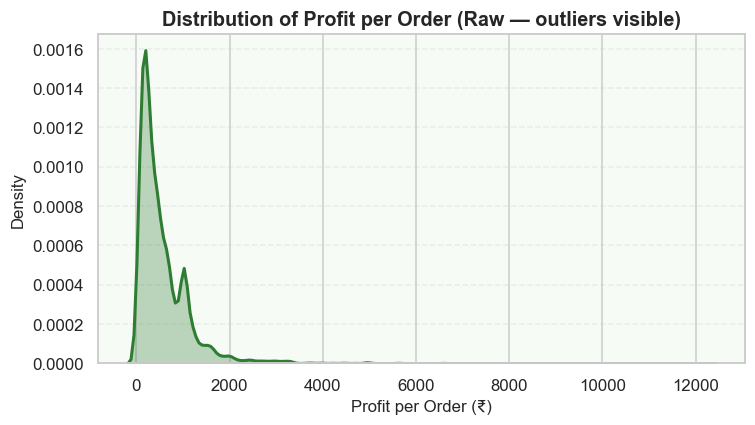

count    50000.000000
mean       567.844102
std        636.206813
min         29.450000
25%        183.460000
50%        377.150000
75%        737.860000
max      12205.200000
Name: profit, dtype: float64

In [15]:
# Profit distribution — RAW (before Winsorization)
plt.figure(figsize=(7,4))
sns.kdeplot(df['profit'], color='#2e7d32', fill=True, alpha=0.3, linewidth=2)
plt.xlabel('Profit per Order (₹)', fontsize=11)
plt.ylabel('Density', fontsize=11)
plt.title('Distribution of Profit per Order (Raw — outliers visible)', fontsize=13, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.gca().set_facecolor(BG_COLOR)
plt.tight_layout(); plt.show()
df['profit'].describe()

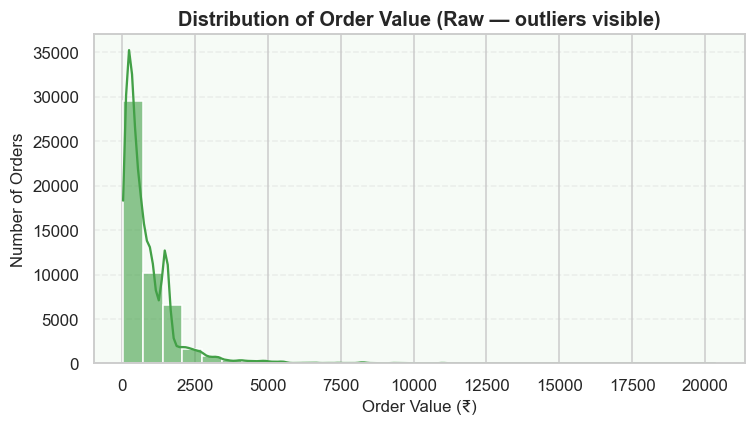

count    50000.000000
mean       857.809680
std       1026.647042
min         37.000000
25%        262.000000
50%        552.000000
75%       1103.000000
max      20342.000000
Name: order_value, dtype: float64

In [16]:
# Order value distribution — RAW
plt.figure(figsize=(7,4))
sns.histplot(df['order_value'], kde=True, color='#43a047', bins=30, alpha=0.6)
plt.xlabel('Order Value (₹)', fontsize=11)
plt.ylabel('Number of Orders', fontsize=11)
plt.title('Distribution of Order Value (Raw — outliers visible)', fontsize=13, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.gca().set_facecolor(BG_COLOR)
plt.tight_layout(); plt.show()
df['order_value'].describe()

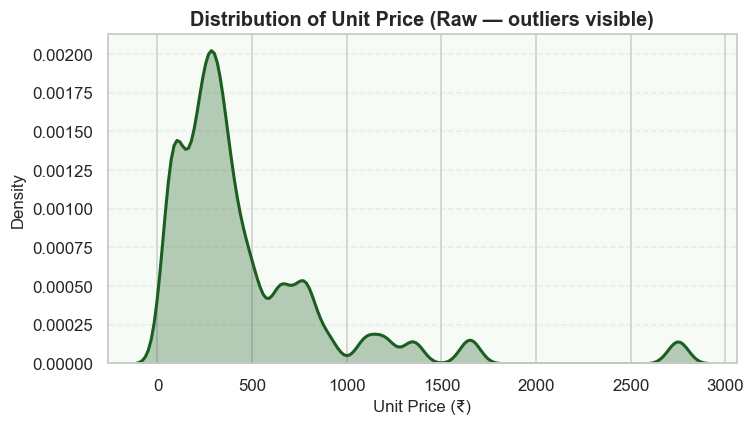

count    50000.000000
mean       465.740000
std        468.186873
min         49.000000
25%        199.000000
50%        299.000000
75%        549.000000
max       2749.000000
Name: unit_price, dtype: float64

In [17]:
# Unit price distribution — RAW
plt.figure(figsize=(7,4))
sns.kdeplot(df['unit_price'], color='#1b5e20', fill=True, alpha=0.3, linewidth=2)
plt.xlabel('Unit Price (₹)', fontsize=11)
plt.ylabel('Density', fontsize=11)
plt.title('Distribution of Unit Price (Raw — outliers visible)', fontsize=13, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.gca().set_facecolor(BG_COLOR)
plt.tight_layout(); plt.show()
df['unit_price'].describe()

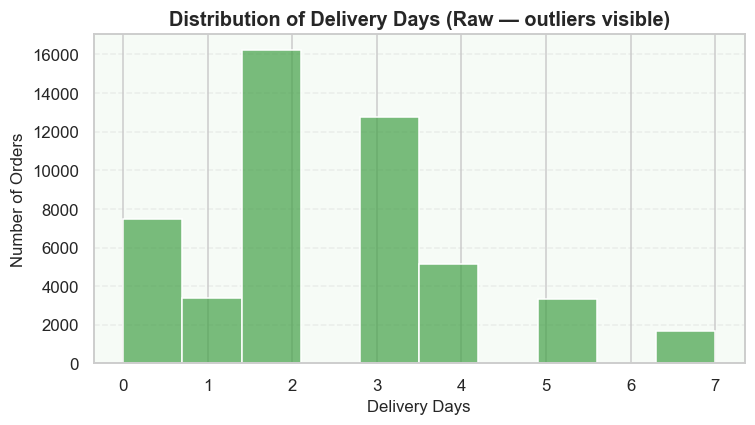

count    50000.000000
mean         2.461700
std          1.596879
min          0.000000
25%          2.000000
50%          2.000000
75%          3.000000
max          7.000000
Name: delivery_days, dtype: float64

In [18]:
# Delivery days distribution — RAW
plt.figure(figsize=(7,4))
sns.histplot(df['delivery_days'], color='#43a047', bins=10, alpha=0.7)
plt.xlabel('Delivery Days', fontsize=11)
plt.ylabel('Number of Orders', fontsize=11)
plt.title('Distribution of Delivery Days (Raw — outliers visible)', fontsize=13, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.gca().set_facecolor(BG_COLOR)
plt.tight_layout(); plt.show()
df['delivery_days'].describe()

In [19]:
# Cap outliers using IQR clipping (Winsorization)
# This reduces distortion in aggregated charts without removing rows
cols_to_cap = ['order_value', 'unit_price', 'profit', 'delivery_days']

for col in cols_to_cap:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr    = q3 - q1
    lower  = q1 - 1.5 * iqr
    upper  = q3 + 1.5 * iqr
    df[col] = df[col].clip(lower=lower, upper=upper)
    print(f"{col}: capped to [{lower:.1f},  {upper:.1f}]")

order_value: capped to [-999.5,  2364.5]
unit_price: capped to [-326.0,  1074.0]
profit: capped to [-648.1,  1569.5]
delivery_days: capped to [0.5,  4.5]


After capping, the distributions below show the cleaned data. The shape is preserved — only the extreme tails are removed. These are the values used in all subsequent analysis.

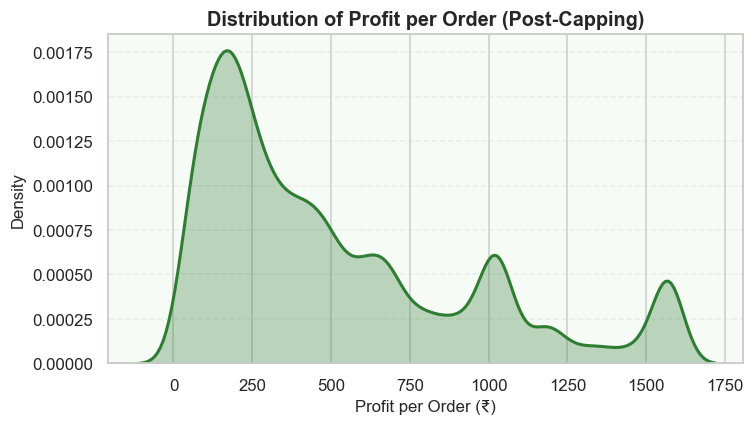

count    50000.000000
mean       518.091094
std        426.055819
min         29.450000
25%        183.460000
50%        377.150000
75%        737.860000
max       1569.460000
Name: profit, dtype: float64

In [20]:
# Profit distribution — post Winsorization
plt.figure(figsize=(7,4))
sns.kdeplot(df['profit'], color='#2e7d32', fill=True, alpha=0.3, linewidth=2)
plt.xlabel('Profit per Order (₹)', fontsize=11)
plt.ylabel('Density', fontsize=11)
plt.title('Distribution of Profit per Order (Post-Capping)', fontsize=13, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.gca().set_facecolor(BG_COLOR)
plt.tight_layout(); plt.show()
df['profit'].describe()

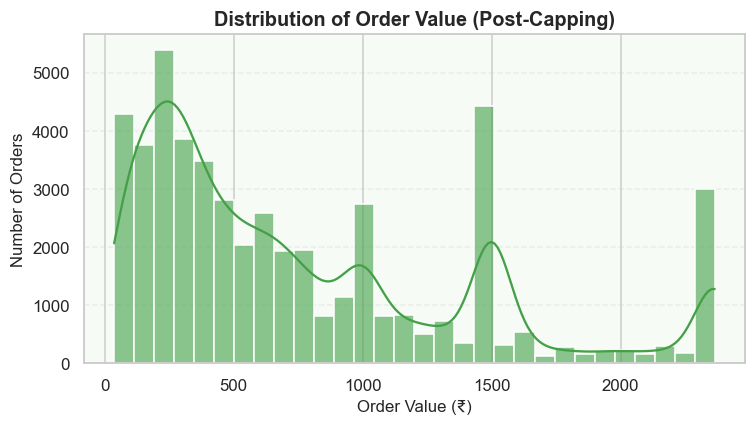

count    50000.000000
mean       768.273240
std        644.341681
min         37.000000
25%        262.000000
50%        552.000000
75%       1103.000000
max       2364.500000
Name: order_value, dtype: float64

In [21]:
# Order value distribution — post Winsorization
plt.figure(figsize=(7,4))
sns.histplot(df['order_value'], kde=True, color='#43a047', bins=30, alpha=0.6)
plt.xlabel('Order Value (₹)', fontsize=11)
plt.ylabel('Number of Orders', fontsize=11)
plt.title('Distribution of Order Value (Post-Capping)', fontsize=13, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.gca().set_facecolor(BG_COLOR)
plt.tight_layout(); plt.show()
df['order_value'].describe()

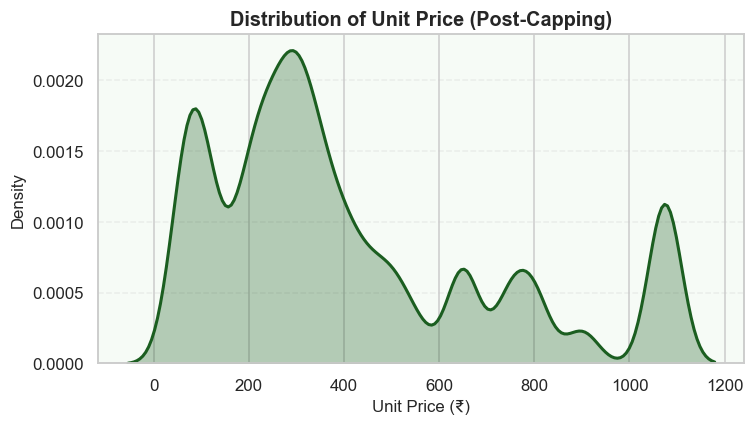

count    50000.000000
mean       413.832500
std        302.120757
min         49.000000
25%        199.000000
50%        299.000000
75%        549.000000
max       1074.000000
Name: unit_price, dtype: float64

In [22]:
# Unit price distribution — post Winsorization
plt.figure(figsize=(7,4))
sns.kdeplot(df['unit_price'], color='#1b5e20', fill=True, alpha=0.3, linewidth=2)
plt.xlabel('Unit Price (₹)', fontsize=11)
plt.ylabel('Density', fontsize=11)
plt.title('Distribution of Unit Price (Post-Capping)', fontsize=13, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.gca().set_facecolor(BG_COLOR)
plt.tight_layout(); plt.show()
df['unit_price'].describe()

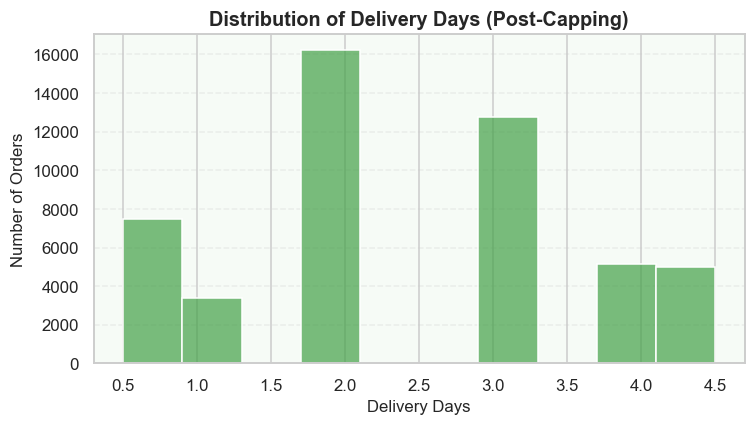

count    50000.000000
mean         2.420060
std          1.233094
min          0.500000
25%          2.000000
50%          2.000000
75%          3.000000
max          4.500000
Name: delivery_days, dtype: float64

In [23]:
# Delivery days distribution — post Winsorization
plt.figure(figsize=(7,4))
sns.histplot(df['delivery_days'], color='#43a047', bins=10, alpha=0.7)
plt.xlabel('Delivery Days', fontsize=11)
plt.ylabel('Number of Orders', fontsize=11)
plt.title('Distribution of Delivery Days (Post-Capping)', fontsize=13, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.gca().set_facecolor(BG_COLOR)
plt.tight_layout(); plt.show()
df['delivery_days'].describe()

<div style="display:inline-block;background-color:#e8f2ff;border-radius:9999px;padding:8px 20px;font-size:20px;font-weight:700;color:#111;">6. Exploratory Data Analysis</div>

<div style="display:inline-block;background-color:#e8f5e9;border-radius:9999px;padding:6px 18px;font-size:17px;font-weight:700;color:#111;">6.1 Univariate Analysis</div>

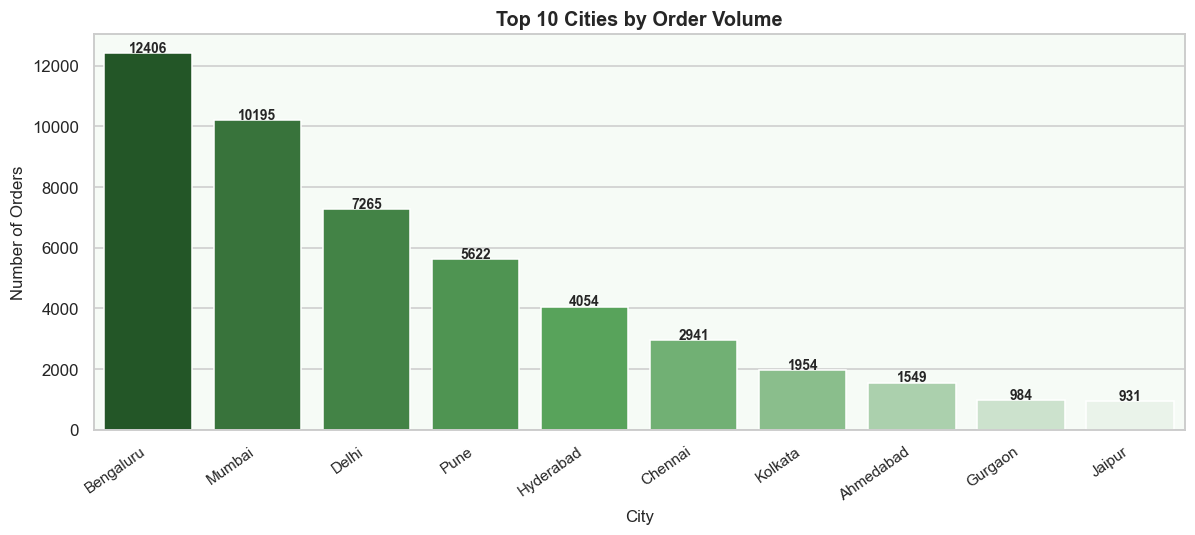

In [24]:
# Top 10 cities by order volume
city_counts = df['city'].value_counts().head(10).reset_index()
city_counts.columns = ['city', 'order_count']

plt.figure(figsize=(11,5))
ax = sns.barplot(data=city_counts, x='city', y='order_count',
                 hue='city', palette=UGAOO_GREEN[:10], legend=False)
for bar in ax.patches:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
            int(bar.get_height()), ha='center', fontsize=9, fontweight='bold')
plt.xticks(rotation=35, ha='right', fontsize=10)
plt.xlabel('City', fontsize=11); plt.ylabel('Number of Orders', fontsize=11)
plt.title('Top 10 Cities by Order Volume', fontsize=13, fontweight='bold')
plt.gca().set_facecolor(BG_COLOR); plt.tight_layout(); plt.show()

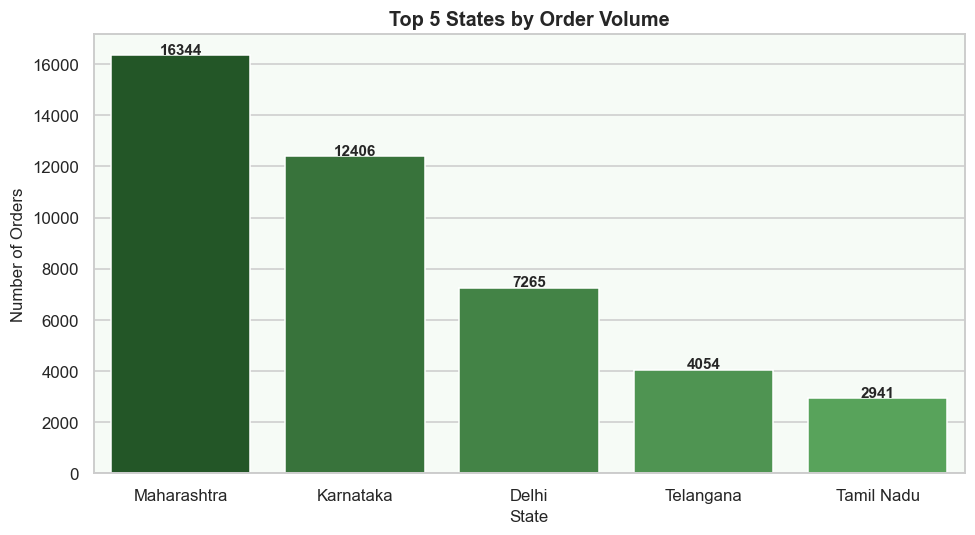

In [25]:
# Top 5 states by order volume
state_counts = df['state'].value_counts().head(5).reset_index()
state_counts.columns = ['state', 'order_count']

plt.figure(figsize=(9,5))
ax = sns.barplot(data=state_counts, x='state', y='order_count',
                 hue='state', palette=UGAOO_GREEN[:5], legend=False)
for bar in ax.patches:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
            int(bar.get_height()), ha='center', fontsize=10, fontweight='bold')
plt.xlabel('State', fontsize=11); plt.ylabel('Number of Orders', fontsize=11)
plt.title('Top 5 States by Order Volume', fontsize=13, fontweight='bold')
plt.gca().set_facecolor(BG_COLOR); plt.tight_layout(); plt.show()

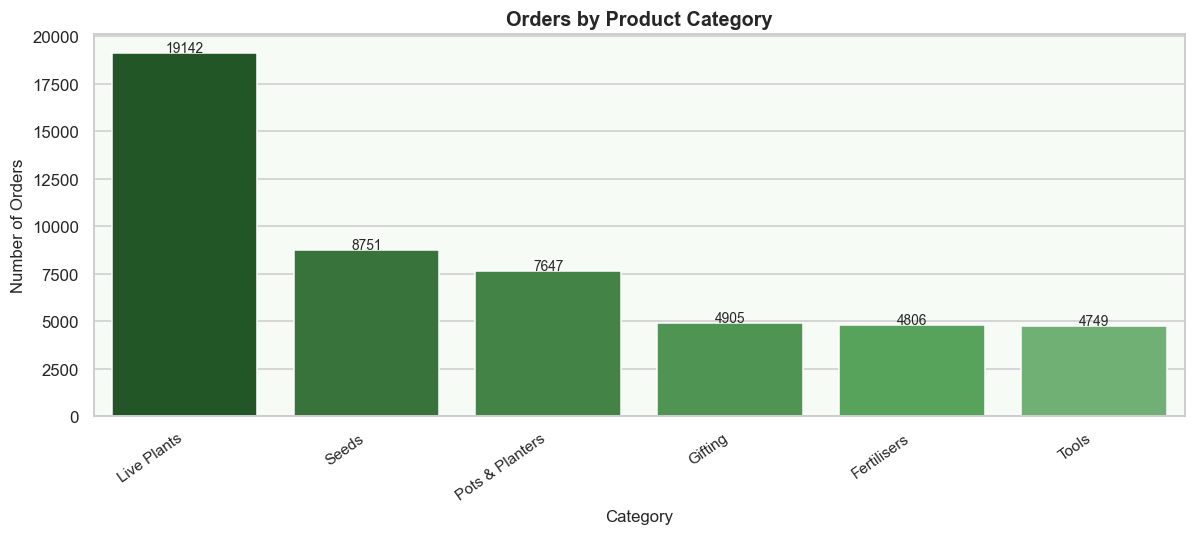

In [26]:
# Orders by product category
category_counts = df['category'].value_counts().reset_index()
category_counts.columns = ['category', 'order_count']

plt.figure(figsize=(11,5))
ax = sns.barplot(data=category_counts, x='category', y='order_count',
                 hue='category', palette=UGAOO_GREEN[:len(category_counts)], legend=False)
for bar in ax.patches:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
            int(bar.get_height()), ha='center', fontsize=9)
plt.xticks(rotation=35, ha='right', fontsize=10)
plt.xlabel('Category', fontsize=11); plt.ylabel('Number of Orders', fontsize=11)
plt.title('Orders by Product Category', fontsize=13, fontweight='bold')
plt.gca().set_facecolor(BG_COLOR); plt.tight_layout(); plt.show()

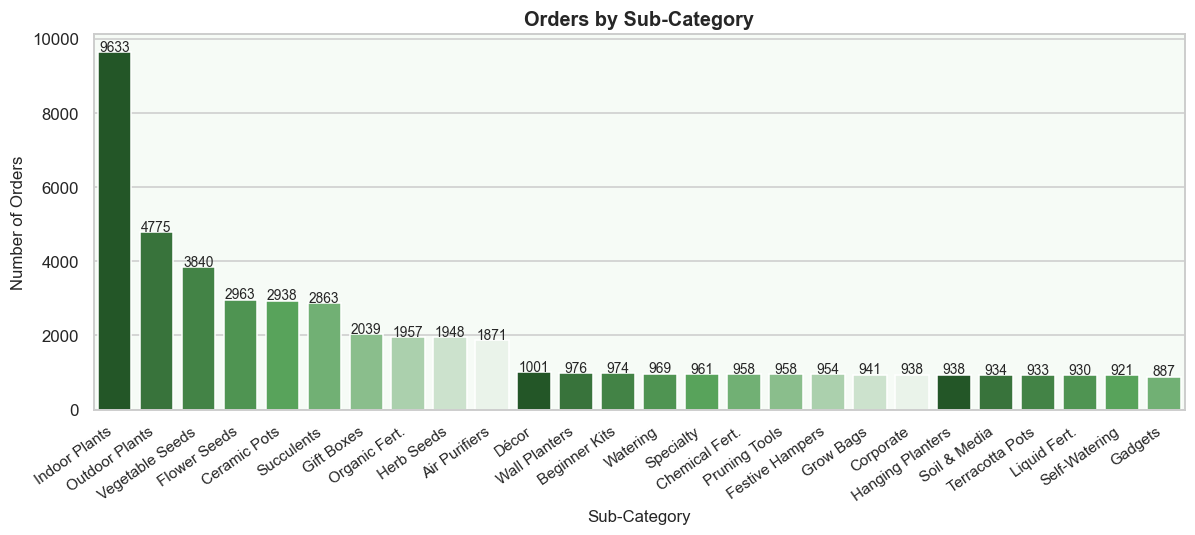

In [27]:
# Orders by sub-category
sub_counts = df['sub_category'].value_counts().reset_index()
sub_counts.columns = ['sub_category', 'order_count']

plt.figure(figsize=(11,5))
ax = sns.barplot(data=sub_counts, x='sub_category', y='order_count',
                 hue='sub_category', palette=UGAOO_GREEN[:len(sub_counts)], legend=False)
for bar in ax.patches:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
            int(bar.get_height()), ha='center', fontsize=9)
plt.xticks(rotation=35, ha='right', fontsize=10)
plt.xlabel('Sub-Category', fontsize=11); plt.ylabel('Number of Orders', fontsize=11)
plt.title('Orders by Sub-Category', fontsize=13, fontweight='bold')
plt.gca().set_facecolor(BG_COLOR); plt.tight_layout(); plt.show()

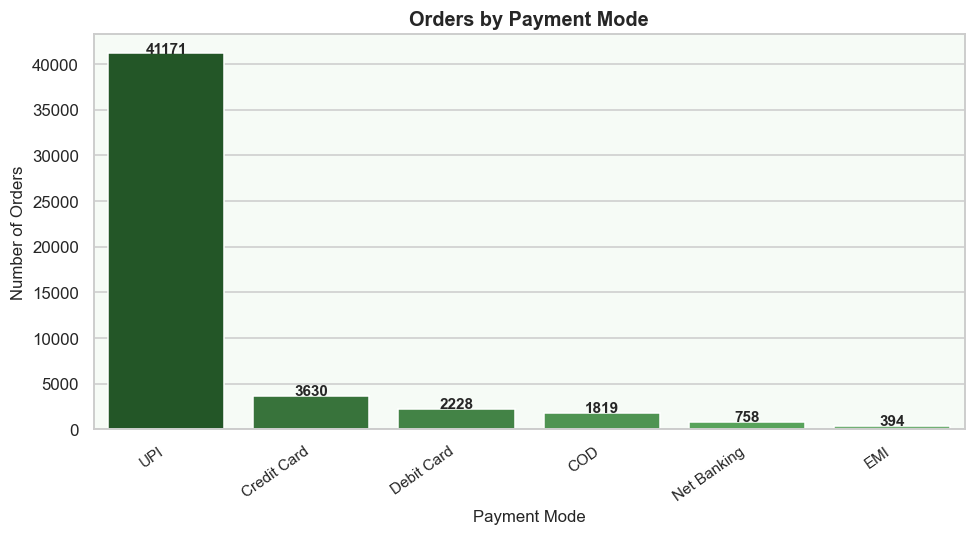

In [28]:
# Orders by payment mode
payment_counts = df['payment_mode'].value_counts().reset_index()
payment_counts.columns = ['payment_mode', 'order_count']

plt.figure(figsize=(9,5))
ax = sns.barplot(data=payment_counts, x='payment_mode', y='order_count',
                 hue='payment_mode', palette=UGAOO_GREEN[:len(payment_counts)], legend=False)
for bar in ax.patches:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
            int(bar.get_height()), ha='center', fontsize=10, fontweight='bold')
plt.xticks(rotation=35, ha='right', fontsize=10)
plt.xlabel('Payment Mode',fontsize=11); plt.ylabel('Number of Orders', fontsize=11)
plt.title('Orders by Payment Mode', fontsize=13, fontweight='bold')
plt.gca().set_facecolor(BG_COLOR); plt.tight_layout(); plt.show()

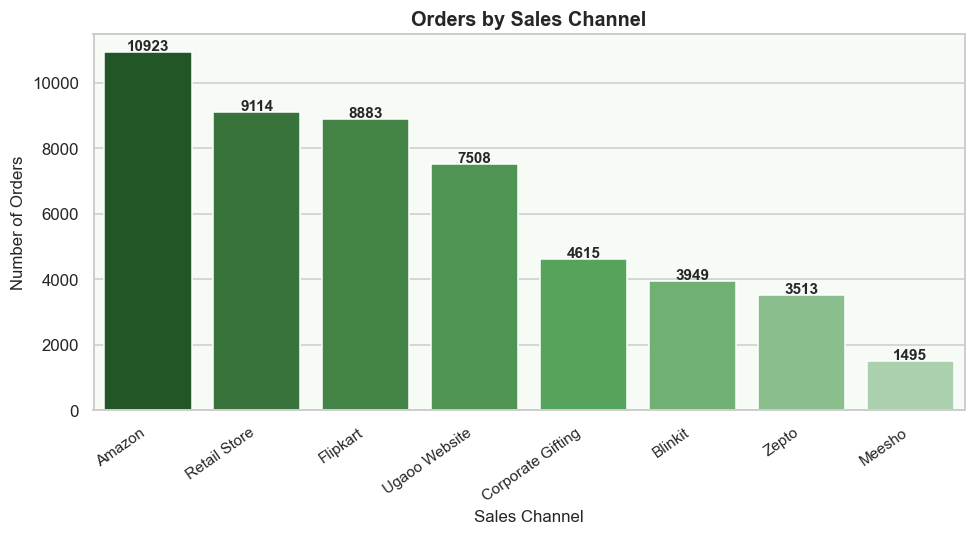

In [29]:
# Orders by sales channel
channel_counts = df['channel'].value_counts().reset_index()
channel_counts.columns = ['channel', 'order_count']

plt.figure(figsize=(9,5))
ax = sns.barplot(data=channel_counts, x='channel', y='order_count',
                 hue='channel', palette=UGAOO_GREEN[:len(channel_counts)], legend=False)
for bar in ax.patches:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
            int(bar.get_height()), ha='center', fontsize=10, fontweight='bold')
plt.xticks(rotation=35, ha='right', fontsize=10)
plt.xlabel('Sales Channel', fontsize=11); plt.ylabel('Number of Orders', fontsize=11)
plt.title('Orders by Sales Channel', fontsize=13, fontweight='bold')
plt.gca().set_facecolor(BG_COLOR); plt.tight_layout(); plt.show()

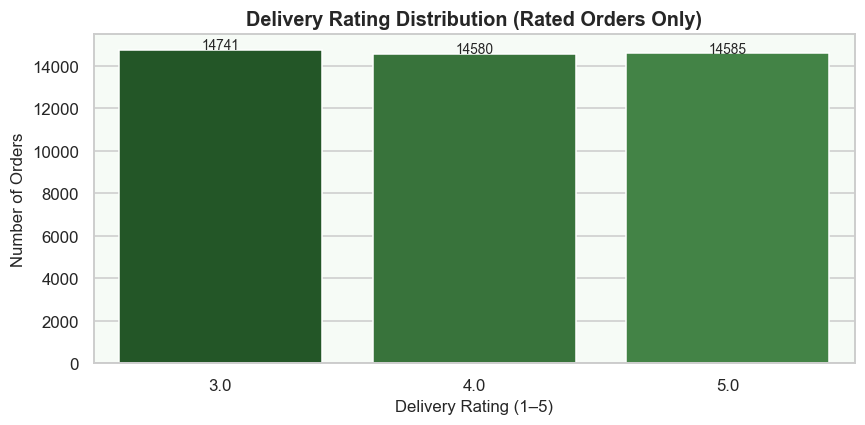

In [30]:
# Delivery rating distribution (excludes customers who did not rate)
rating_counts = (df[df['delivery_rating'] != 'No Rating']['delivery_rating']
                 .value_counts().sort_index().reset_index())
rating_counts.columns = ['rating', 'order_count']

plt.figure(figsize=(8,4))
ax = sns.barplot(data=rating_counts, x='rating', y='order_count',
                 hue='rating', palette=UGAOO_GREEN[:len(rating_counts)], legend=False)
for bar in ax.patches:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
            int(bar.get_height()), ha='center', fontsize=9)
plt.xlabel('Delivery Rating (1–5)', fontsize=11)
plt.ylabel('Number of Orders', fontsize=11)
plt.title('Delivery Rating Distribution (Rated Orders Only)', fontsize=13, fontweight='bold')
plt.gca().set_facecolor(BG_COLOR); plt.tight_layout(); plt.show()

<div style="background:#f9fbe7;border-left:5px solid #aed581;padding:16px;border-radius:8px;color:#000;">

**Univariate Insights**

- Profit and order value are right-skewed — a small proportion of orders contribute disproportionately high revenue, which is normal for a plant e-commerce brand with premium SKUs.
- Order volume is concentrated in a few cities and states — geographic dependence is a clear business risk.
- Live Plants dominate order volume . 
- UPI and Credit Card are the most used payment modes. COD still holds a meaningful share, which matters for return rate analysis.

</div>

<div style="display:inline-block;background-color:#e8f5e9;border-radius:9999px;padding:6px 18px;font-size:17px;font-weight:700;color:#111;">6.2 Bivariate Analysis</div>

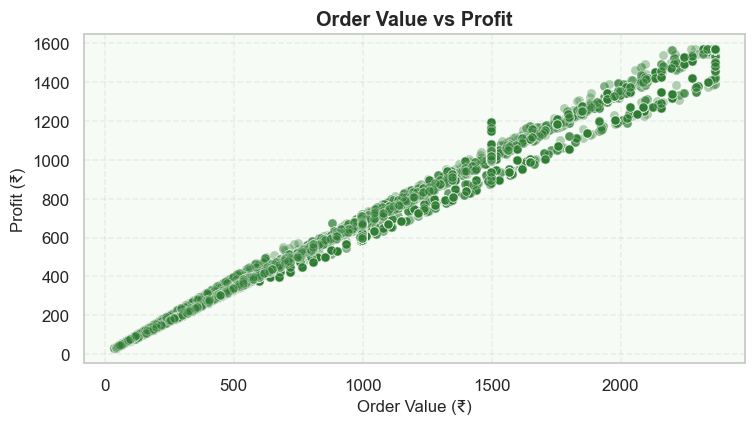

In [31]:
# Order value vs Profit
plt.figure(figsize=(7,4))
sns.scatterplot(x=df['order_value'], y=df['profit'], color='#2e7d32', alpha=0.35)
plt.xlabel('Order Value (₹)', fontsize=11); plt.ylabel('Profit (₹)', fontsize=11)
plt.title('Order Value vs Profit', fontsize=13, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.3)
plt.gca().set_facecolor(BG_COLOR); plt.tight_layout(); plt.show()

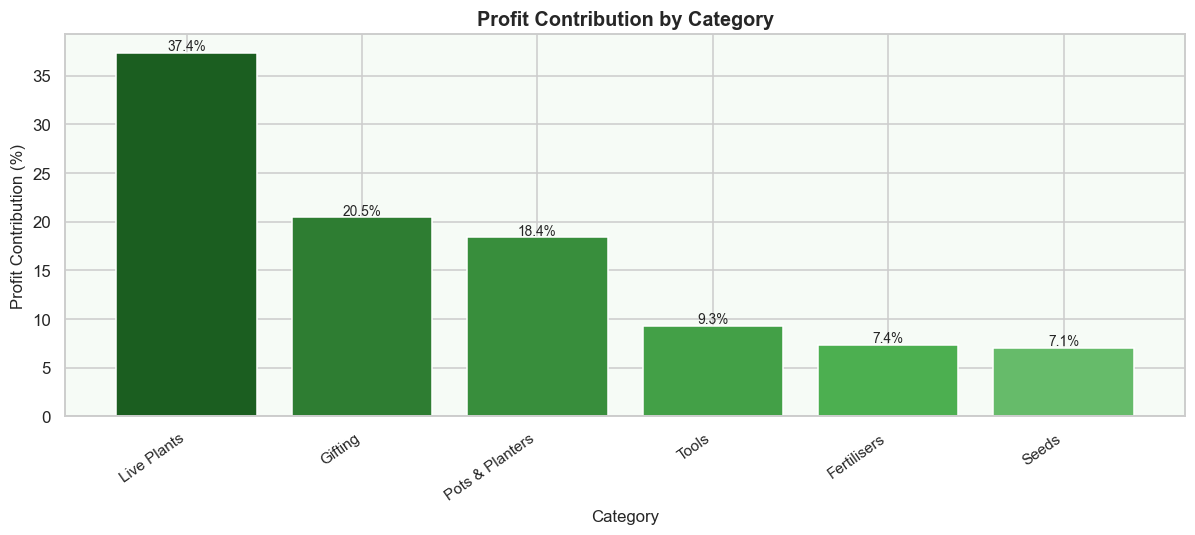

In [32]:
# Category-wise profit contribution
total_profit    = df['profit'].sum()
category_profit = df.groupby('category')['profit'].sum()
cont_cat_profit = (category_profit / total_profit * 100).sort_values(ascending=False)

plt.figure(figsize=(11,5))
bars = plt.bar(cont_cat_profit.index, cont_cat_profit.values,
               color=UGAOO_GREEN[:len(cont_cat_profit)])
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, h+0.2, f'{h:.1f}%', ha='center', fontsize=9)
plt.xlabel('Category', fontsize=11); plt.ylabel('Profit Contribution (%)', fontsize=11)
plt.title('Profit Contribution by Category', fontsize=13, fontweight='bold')
plt.xticks(rotation=35, ha='right', fontsize=10)
plt.gca().set_facecolor(BG_COLOR); plt.tight_layout(); plt.show()

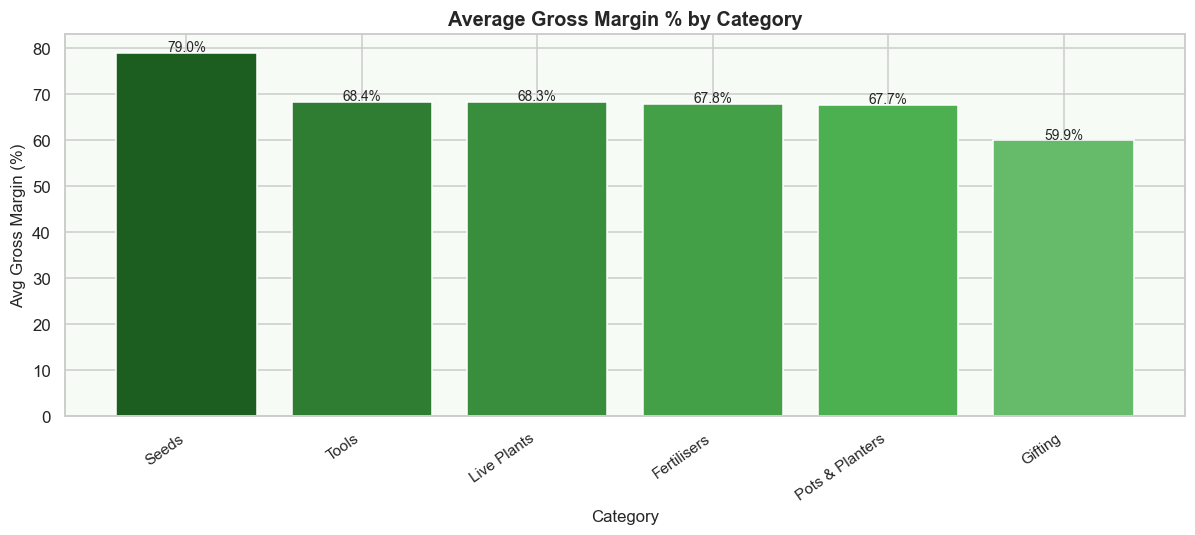

In [33]:
# Average gross margin % by category — backs the Seeds/Succulents insight
cat_margin = df.groupby('category')['gross_margin_pct'].mean().sort_values(ascending=False).reset_index()
cat_margin.columns = ['category', 'avg_margin_pct']

plt.figure(figsize=(11,5))
bars = plt.bar(cat_margin['category'], cat_margin['avg_margin_pct'], color=UGAOO_GREEN[:len(cat_margin)])
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, h+0.3, f'{h:.1f}%', ha='center', fontsize=9)
plt.xlabel('Category', fontsize=11); plt.ylabel('Avg Gross Margin (%)', fontsize=11)
plt.title('Average Gross Margin % by Category', fontsize=13, fontweight='bold')
plt.xticks(rotation=35, ha='right', fontsize=10)
plt.gca().set_facecolor(BG_COLOR); plt.tight_layout(); plt.show()

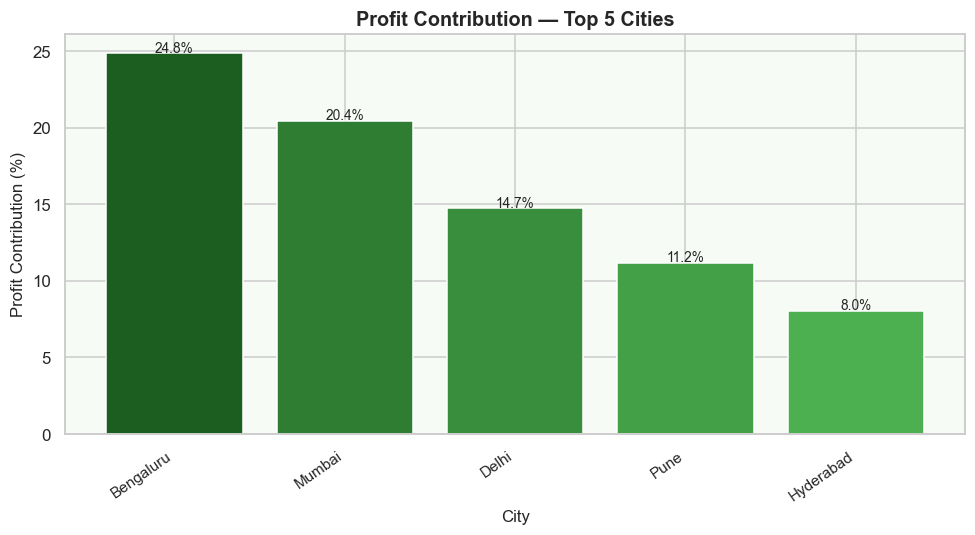

In [34]:
# Top 5 cities by profit contribution
city_profit = df.groupby('city')['profit'].sum().sort_values(ascending=False)
cont_city   = (city_profit / total_profit * 100).head(5)

plt.figure(figsize=(9,5))
bars = plt.bar(cont_city.index, cont_city.values, color=UGAOO_GREEN[:5])
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, h+0.1, f'{h:.1f}%', ha='center', fontsize=9)
plt.xlabel('City', fontsize=11); plt.ylabel('Profit Contribution (%)', fontsize=11)
plt.title('Profit Contribution — Top 5 Cities', fontsize=13, fontweight='bold')
plt.xticks(rotation=35, ha='right', fontsize=10)
plt.gca().set_facecolor(BG_COLOR); plt.tight_layout(); plt.show()

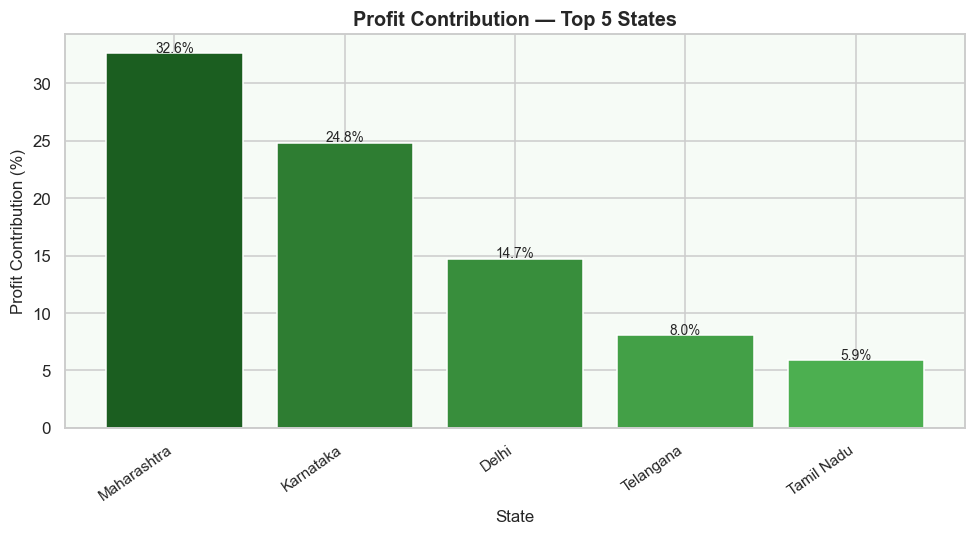

In [35]:
# Top 5 states by profit contribution
state_profit = df.groupby('state')['profit'].sum().sort_values(ascending=False)
cont_state   = (state_profit / total_profit * 100).head(5)

plt.figure(figsize=(9,5))
bars = plt.bar(cont_state.index, cont_state.values, color=UGAOO_GREEN[:5])
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, h+0.1, f'{h:.1f}%', ha='center', fontsize=9)
plt.xlabel('State', fontsize=11); plt.ylabel('Profit Contribution (%)', fontsize=11)
plt.title('Profit Contribution — Top 5 States', fontsize=13, fontweight='bold')
plt.xticks(rotation=35, ha='right', fontsize=10)
plt.gca().set_facecolor(BG_COLOR); plt.tight_layout(); plt.show()

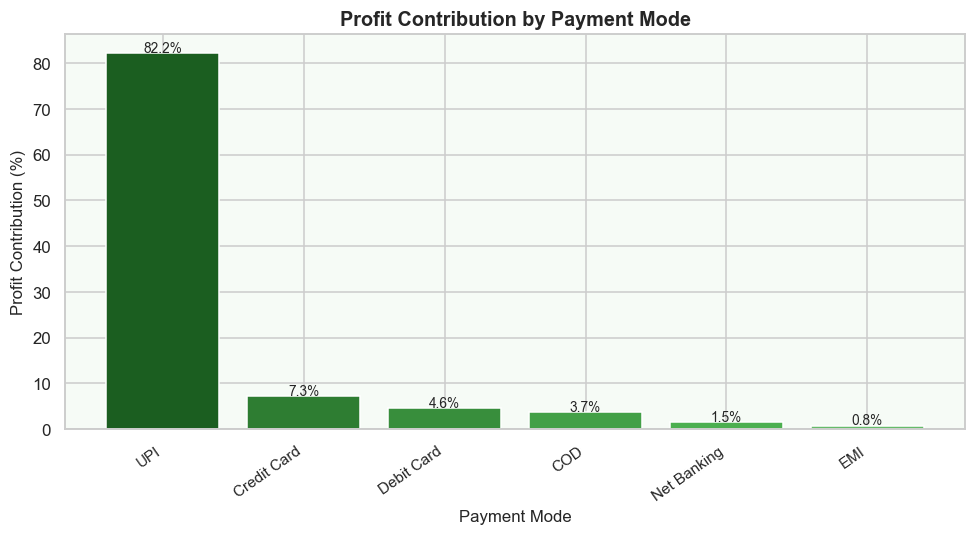

In [36]:
# Profit contribution by payment mode
pm_profit = df.groupby('payment_mode')['profit'].sum()
cont_pm   = (pm_profit / total_profit * 100).sort_values(ascending=False)

plt.figure(figsize=(9,5))
bars = plt.bar(cont_pm.index, cont_pm.values, color=UGAOO_GREEN[:len(cont_pm)])
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, h+0.2, f'{h:.1f}%', ha='center', fontsize=9)
plt.xlabel('Payment Mode', fontsize=11); plt.ylabel('Profit Contribution (%)', fontsize=11)
plt.title('Profit Contribution by Payment Mode', fontsize=13, fontweight='bold')
plt.xticks(rotation=35, ha='right', fontsize=10)
plt.gca().set_facecolor(BG_COLOR); plt.tight_layout(); plt.show()

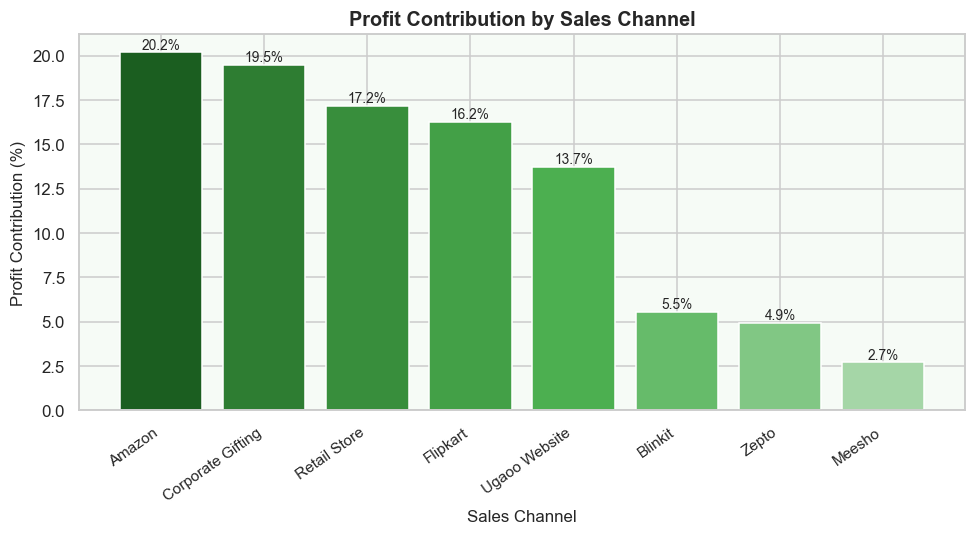

In [37]:
# Profit contribution by sales channel
channel_profit = df.groupby('channel')['profit'].sum()
cont_ch        = (channel_profit / total_profit * 100).sort_values(ascending=False)

plt.figure(figsize=(9,5))
bars = plt.bar(cont_ch.index, cont_ch.values, color=UGAOO_GREEN[:len(cont_ch)])
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, h+0.2, f'{h:.1f}%', ha='center', fontsize=9)
plt.xlabel('Sales Channel', fontsize=11); plt.ylabel('Profit Contribution (%)', fontsize=11)
plt.title('Profit Contribution by Sales Channel', fontsize=13, fontweight='bold')
plt.xticks(rotation=35, ha='right', fontsize=10)
plt.gca().set_facecolor(BG_COLOR); plt.tight_layout(); plt.show()

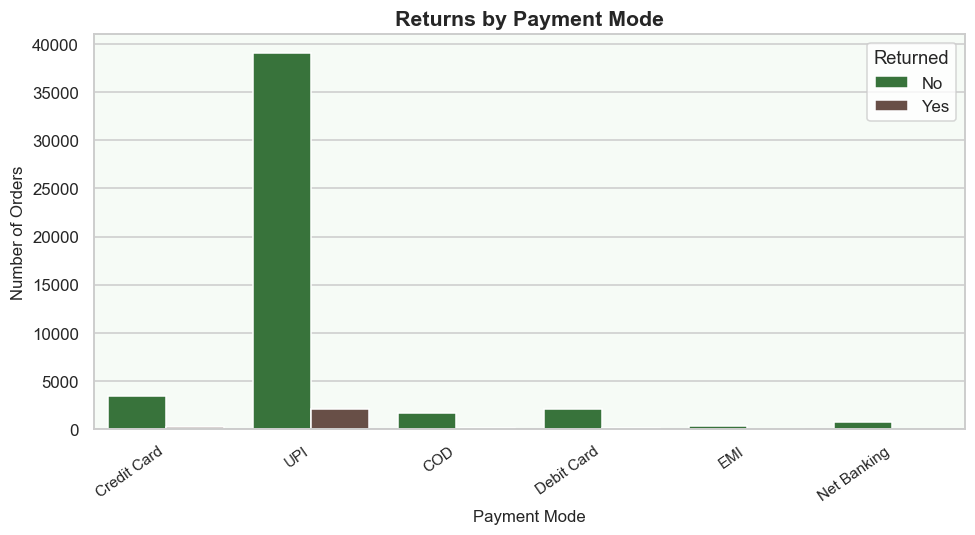

In [38]:
# Payment mode vs product returns
plt.figure(figsize=(9,5))
sns.countplot(data=df, x='payment_mode', hue='is_returned',
              palette=['#2E7D32', UGAOO_BROWN])
plt.title('Returns by Payment Mode', fontsize=14, fontweight='bold')
plt.xlabel('Payment Mode', fontsize=11); plt.ylabel('Number of Orders', fontsize=11)
plt.xticks(rotation=35, ha='right', fontsize=10)
plt.legend(title='Returned', labels=['No', 'Yes'])
plt.gca().set_facecolor(BG_COLOR); plt.tight_layout(); plt.show()

Unique values in is_returned: <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str


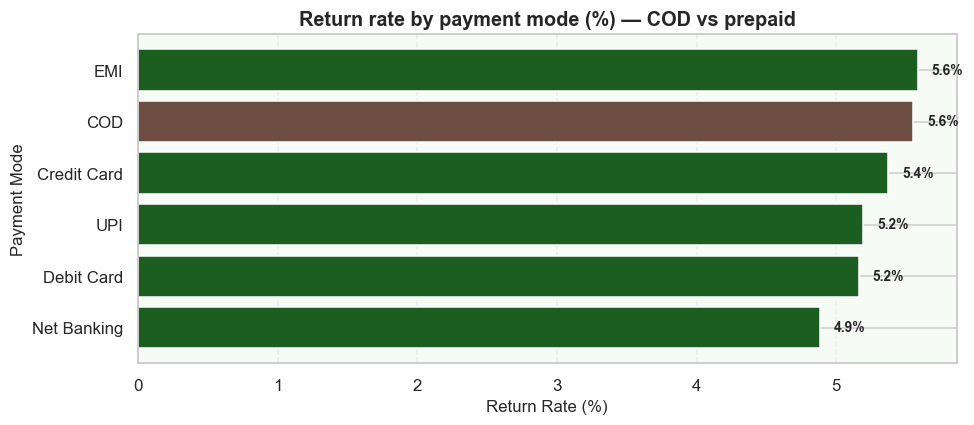

COD return rate      : 5.6%
Prepaid average rate : 5.2%
Absolute difference  : 0.3 percentage points


In [39]:
# Return rate by payment mode — what % of orders in each mode resulted in a replacement claim
# Using replacement_claimed column (values: "Yes"/"No" in original data before feature-eng mapping)
# In the merged df, is_returned mirrors replacement_claimed values

# Simpler and correct approach — check actual unique values first
_ret_vals = df['is_returned'].unique()
print("Unique values in is_returned:", _ret_vals)

# Compute return rate correctly based on actual column values
_yes_val = 'Yes' if 'Yes' in _ret_vals else ('Claimed' if 'Claimed' in _ret_vals else _ret_vals[0])
return_rate = (
    df.groupby('payment_mode')
      .apply(lambda x: (x['is_returned'] == _yes_val).sum() / len(x) * 100)
      .reset_index()
)
return_rate.columns = ['payment_mode', 'return_rate_pct']
return_rate = return_rate.sort_values('return_rate_pct', ascending=False).reset_index(drop=True)

bar_colors = [UGAOO_BROWN if pm == 'COD' else UGAOO_GREEN[0] for pm in return_rate['payment_mode']]

plt.figure(figsize=(9, 4))
bars = plt.barh(return_rate['payment_mode'][::-1], return_rate['return_rate_pct'][::-1], color=bar_colors[::-1])
for bar, val in zip(bars, return_rate['return_rate_pct'][::-1]):
    plt.text(val + 0.1, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')
plt.xlabel('Return Rate (%)', fontsize=11)
plt.ylabel('Payment Mode', fontsize=11)
plt.title('Return rate by payment mode (%) — COD vs prepaid', fontsize=13, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.gca().set_facecolor(BG_COLOR)
plt.tight_layout(); plt.show()

cod_rate    = return_rate[return_rate['payment_mode'] == 'COD']['return_rate_pct'].values
prepaid_avg = return_rate[return_rate['payment_mode'] != 'COD']['return_rate_pct'].mean()
if len(cod_rate):
    print(f"COD return rate      : {cod_rate[0]:.1f}%")
    print(f"Prepaid average rate : {prepaid_avg:.1f}%")
    print(f"Absolute difference  : {cod_rate[0] - prepaid_avg:.1f} percentage points")
else:
    print(return_rate.to_string(index=False))

<div style="background:#f9fbe7;border-left:5px solid #aed581;padding:16px;border-radius:8px;color:#000;">

**COD vs Prepaid — Return Rate Insight**

The chart above shows return rate as a percentage of orders per payment mode — not raw counts. This is a fairer comparison because payment modes have different order volumes. COD consistently shows a higher return rate than prepaid modes, reflecting lower buyer commitment at checkout. Customers who pay upfront are more intentional about their purchase. Nudging high-value COD orders toward prepaid (with a small incentive like a cashback or free delivery) is one of the most direct ways to reduce reverse logistics costs.
</div>

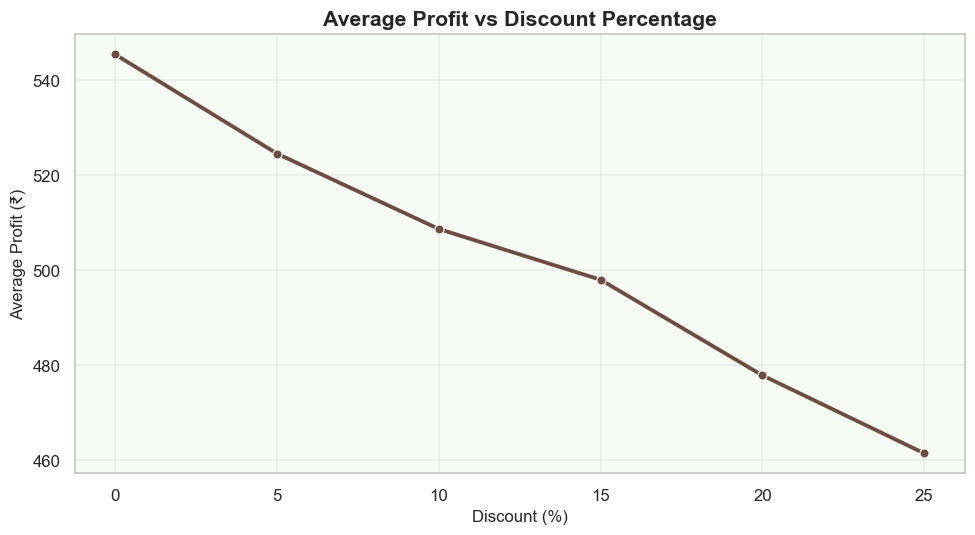

In [40]:
# Average profit at each discount level
discount_profit = df.groupby('discount_pct')['profit'].mean().reset_index()

plt.figure(figsize=(9,5))
sns.lineplot(data=discount_profit, x='discount_pct', y='profit',
             marker='o', color=UGAOO_BROWN, linewidth=2.5)
plt.title('Average Profit vs Discount Percentage', fontsize=14, fontweight='bold')
plt.xlabel('Discount (%)', fontsize=11); plt.ylabel('Average Profit (₹)', fontsize=11)
plt.grid(alpha=0.3); plt.gca().set_facecolor(BG_COLOR); plt.tight_layout(); plt.show()

### Monthly Revenue Trend

The chart below shows monthly revenue across financial years. The x-axis follows calendar month order (April–March for FY alignment). Pay attention to the shape of each year's curve rather than absolute values.

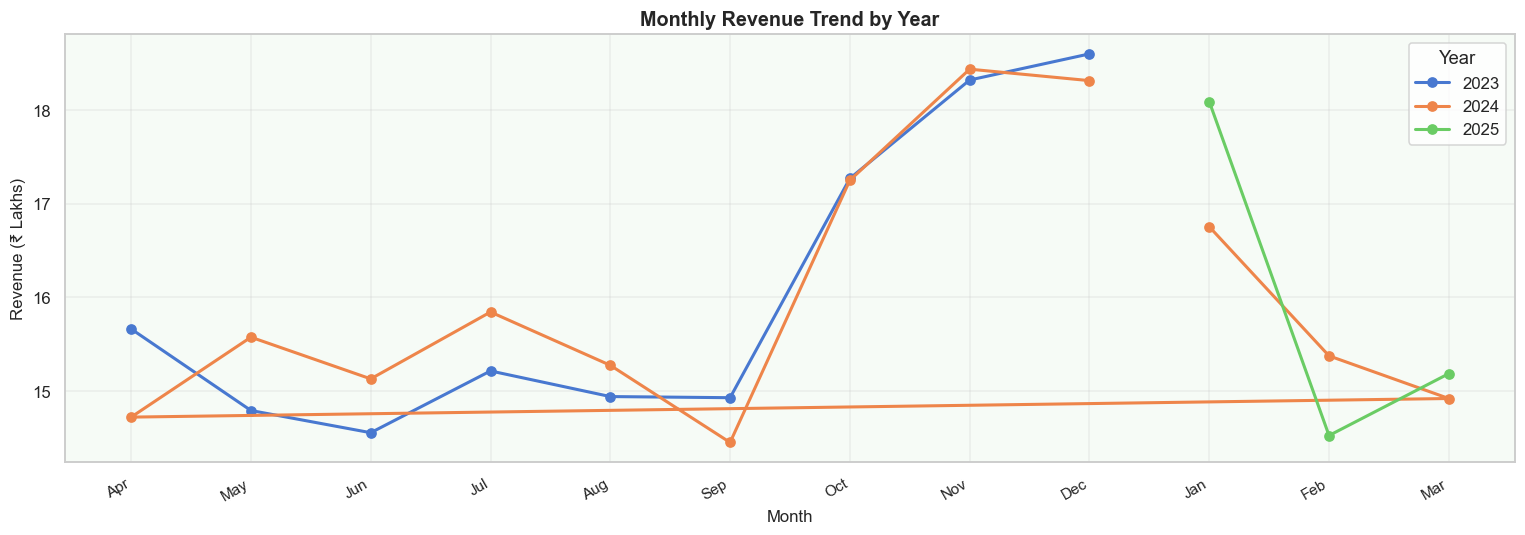

In [41]:
# Monthly revenue trend — sequential month order (Apr to Mar for FY view)
MONTH_ORDER = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

# Use month_name already created; ensure correct ordering
monthly = (df.groupby(['year', 'month', 'month_name'])['order_value']
             .sum().reset_index()
             .sort_values(['year', 'month']))

plt.figure(figsize=(14,5))
for yr, grp in monthly.groupby('year'):
    plt.plot(grp['month_name'], grp['order_value']/1e5,
             marker='o', linewidth=2, label=str(yr))
plt.title('Monthly Revenue Trend by Year', fontsize=13, fontweight='bold')
plt.xlabel('Month', fontsize=11); plt.ylabel('Revenue (₹ Lakhs)', fontsize=11)
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.legend(title='Year'); plt.grid(alpha=0.3)
plt.gca().set_facecolor(BG_COLOR); plt.tight_layout(); plt.show()

**Seasonality interpretation:**

Revenue peaks in Oct–Dec driven by the festive gifting season (Diwali, Christmas) and cooler weather when gardening activity increases. Jan–Mar shows a post-festive dip with a mild recovery as outdoor planting season begins. Jun–Aug tends to be the weakest period — monsoon season reduces outdoor gardening interest. This pattern means inventory and marketing budgets should be weighted toward Q3 (Oct–Dec) and Q1 (Feb–Mar).

  segment  orders    revenue  avg_order
      New   18971 14509039.5 764.800986
Returning   17535 13494209.0 769.558540
    Loyal   13494 10410413.5 771.484623


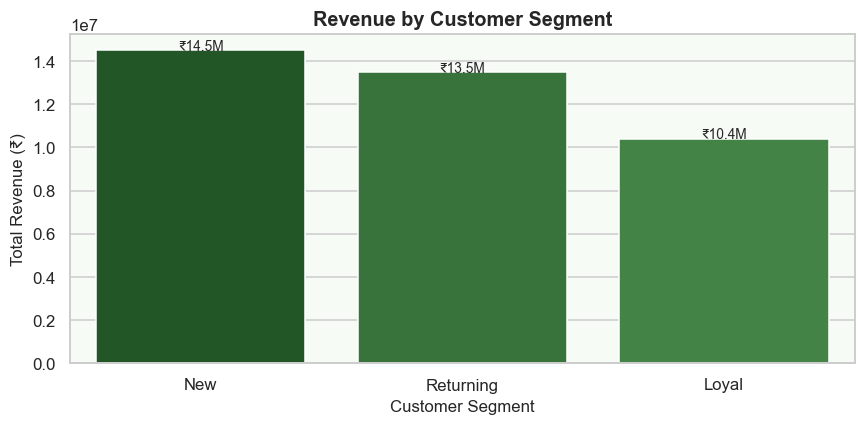

In [42]:
# Revenue and order summary by customer segment
seg_stats = df.groupby('segment').agg(
    orders    = ('order_id', 'count'),
    revenue   = ('order_value', 'sum'),
    avg_order = ('order_value', 'mean')
).reset_index().sort_values('revenue', ascending=False)

print(seg_stats.to_string(index=False))

plt.figure(figsize=(8,4))
ax = sns.barplot(data=seg_stats, x='segment', y='revenue',
                 hue='segment', palette=UGAOO_GREEN[:len(seg_stats)], legend=False)
for bar in ax.patches:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5000,
            f'₹{bar.get_height()/1e6:.1f}M', ha='center', fontsize=9)
plt.xlabel('Customer Segment', fontsize=11); plt.ylabel('Total Revenue (₹)', fontsize=11)
plt.title('Revenue by Customer Segment', fontsize=13, fontweight='bold')
plt.gca().set_facecolor(BG_COLOR); plt.tight_layout(); plt.show()

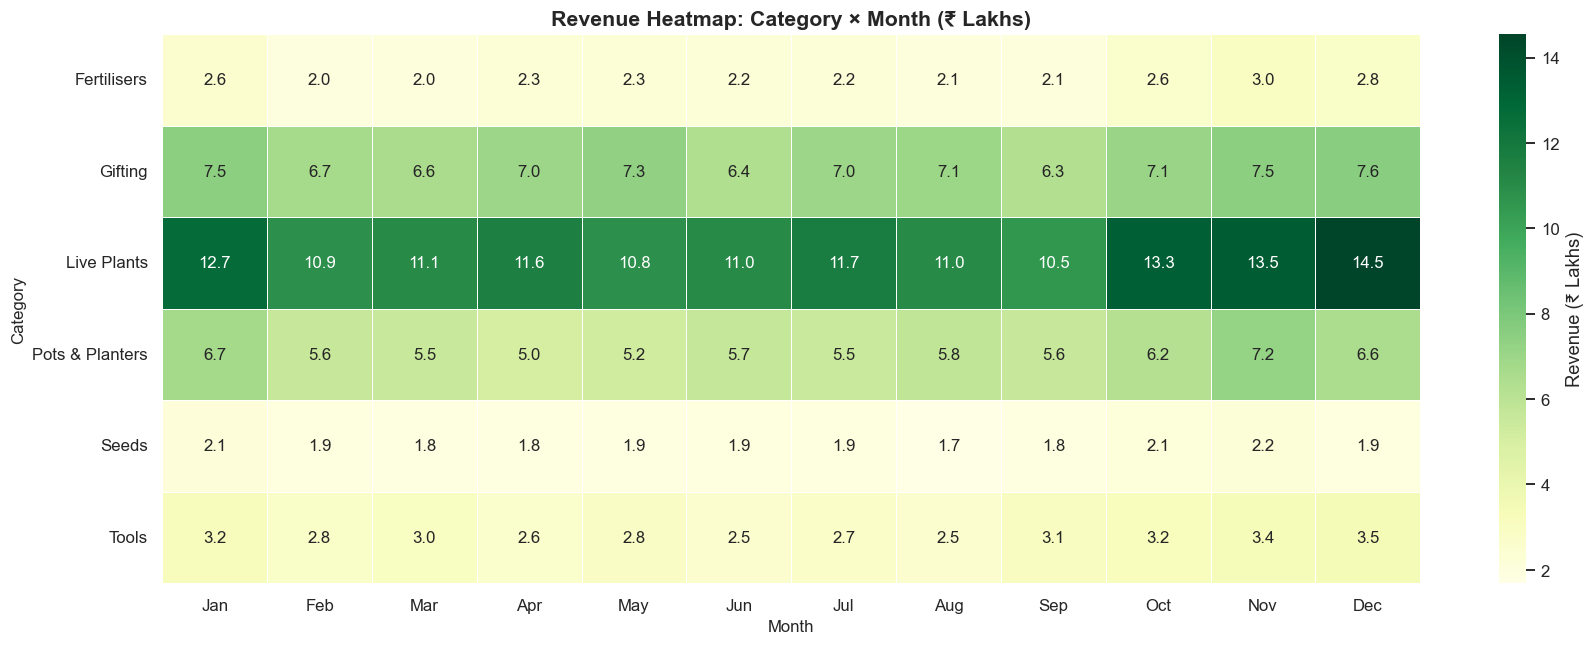

In [43]:
# Revenue heatmap: Category × Month
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

pivot = df.pivot_table(values='order_value', index='category',
                       columns='month_name', aggfunc='sum', fill_value=0)
pivot = pivot.reindex(columns=[m for m in month_order if m in pivot.columns])

plt.figure(figsize=(16,6))
sns.heatmap(pivot/1e5, annot=True, fmt='.1f', cmap='YlGn', linewidths=0.5,
            cbar_kws={'label': 'Revenue (₹ Lakhs)'})
plt.title('Revenue Heatmap: Category × Month (₹ Lakhs)', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=11); plt.ylabel('Category', fontsize=11)
plt.tight_layout(); plt.show()

<div style="display:inline-block;background-color:#e8f5e9;border-radius:9999px;padding:6px 18px;font-size:17px;font-weight:700;color:#111;">6.3 City × Channel Analysis</div>

### City × Channel Sales Analysis

The `city_ch` table contains monthly aggregated sales data broken down by city and sales channel. It has 4,032 rows covering multiple cities, channels, and months, with metrics including revenue, order count, and average order value. This section identifies which channel dominates in metro cities versus non-metro cities, and which city × channel combinations generate the highest revenue — a key input for channel investment decisions.

In [44]:
# City × Channel table — basic exploration
print('Shape:', city_ch.shape)
print('\nColumns:', city_ch.columns.tolist())
city_ch.head()

Shape: (4032, 16)

Columns: ['month', 'fy', 'city', 'state', 'channel', 'total_orders', 'revenue_inr', 'avg_order_value_inr', 'units_sold', 'new_customers', 'returning_customers', 'returns', 'return_rate_pct', 'cancellations', 'discount_orders_pct', 'avg_discount_pct']


,month,fy,city,state,channel,total_orders,revenue_inr,avg_order_value_inr,units_sold,new_customers,returning_customers,returns,return_rate_pct,cancellations,discount_orders_pct,avg_discount_pct
0,Apr-2022,FY23,Bengaluru,Karnataka,Amazon,2496,3674535,1474,2929,521,1099,244,9.8,97,19.4,6.8
1,Apr-2022,FY23,Bengaluru,Karnataka,Flipkart,2196,3386958,1541,3724,489,1056,267,12.2,53,26.6,7.3
2,Apr-2022,FY23,Bengaluru,Karnataka,Ugaoo Website,1541,2303562,1492,2037,381,526,78,5.1,84,42.1,17.1
3,Apr-2022,FY23,Bengaluru,Karnataka,Blinkit,920,879733,958,1327,220,422,62,6.8,54,37.3,11.3
4,Apr-2022,FY23,Bengaluru,Karnataka,Zepto,735,986684,1347,1297,145,369,82,11.2,27,23.5,8.9


In [45]:
city_ch.info()
print('\n')
city_ch.describe()

<class 'pandas.DataFrame'>
RangeIndex: 4032 entries, 0 to 4031
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   month                4032 non-null   str    
 1   fy                   4032 non-null   str    
 2   city                 4032 non-null   str    
 3   state                4032 non-null   str    
 4   channel              4032 non-null   str    
 5   total_orders         4032 non-null   int64  
 6   revenue_inr          4032 non-null   int64  
 7   avg_order_value_inr  4032 non-null   int64  
 8   units_sold           4032 non-null   int64  
 9   new_customers        4032 non-null   int64  
 10  returning_customers  4032 non-null   int64  
 11  returns              4032 non-null   int64  
 12  return_rate_pct      4032 non-null   float64
 13  cancellations        4032 non-null   int64  
 14  discount_orders_pct  4032 non-null   float64
 15  avg_discount_pct     4032 non-null   float64
dtyp

,total_orders,revenue_inr,avg_order_value_inr,units_sold,new_customers,returning_customers,returns,return_rate_pct,cancellations,discount_orders_pct,avg_discount_pct
count,4032.000000,4.032000e+03,4032.000000,4032.000000,4032.000000,4032.000000,4032.000000,4032.000000,4032.000000,4032.000000,4032.000000
mean,540.195437,6.658713e+05,1231.991815,782.106895,163.576885,228.953373,47.906250,8.976935,21.144593,31.590650,12.510739
std,761.635910,9.528420e+05,219.594597,1134.663145,243.550914,333.059624,70.684081,2.297153,32.865236,7.801232,4.342661
min,5.000000,5.276000e+03,850.000000,8.000000,1.000000,2.000000,0.000000,5.000000,0.000000,18.000000,5.000000
25%,84.750000,1.013195e+05,1044.000000,120.000000,24.000000,34.000000,7.000000,7.000000,3.000000,24.900000,8.700000
50%,217.000000,2.620080e+05,1236.000000,309.500000,63.000000,91.000000,19.000000,9.000000,8.000000,31.600000,12.500000
75%,689.000000,8.164828e+05,1423.250000,971.750000,200.000000,287.000000,59.250000,11.000000,25.250000,38.300000,16.300000
max,5714.000000,7.889721e+06,1600.000000,10210.000000,2103.000000,3060.000000,576.000000,13.000000,324.000000,45.000000,20.000000


Using revenue column: revenue_inr


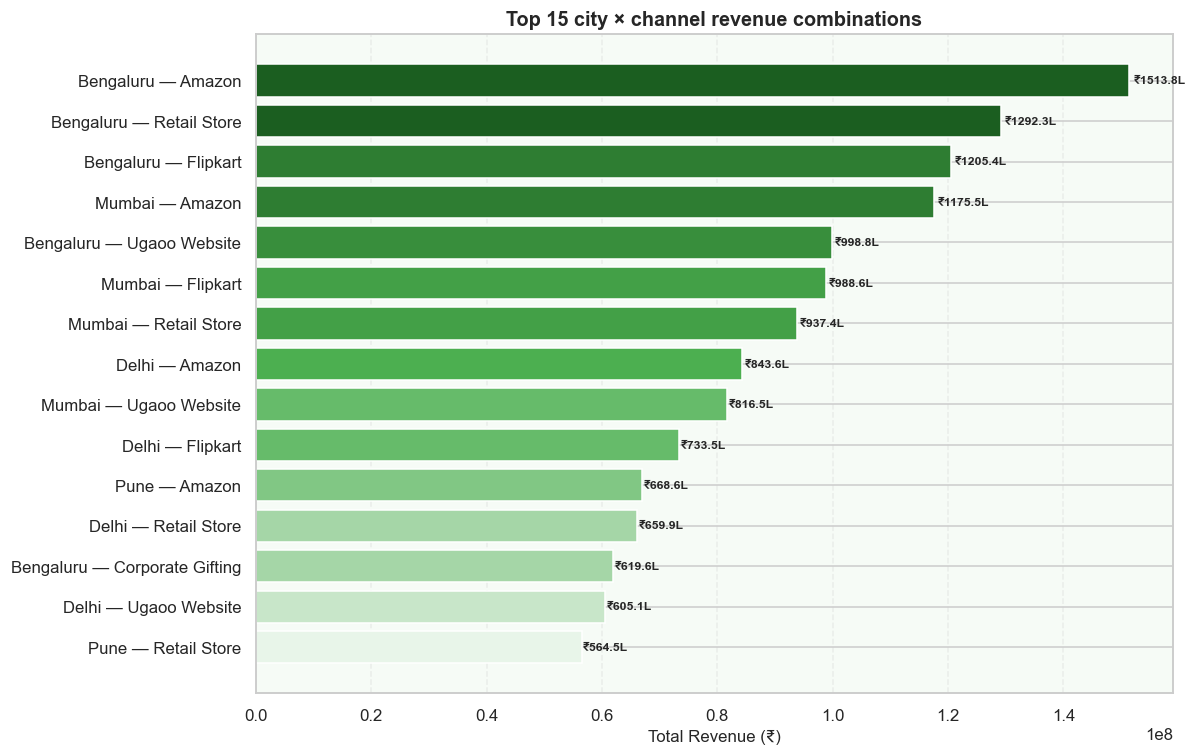

In [46]:
# Top 15 city × channel revenue combinations
# Identify revenue column — try common names
_rev_col = None
for _c in ['revenue', 'total_revenue', 'revenue_inr', 'gmv', 'order_value', 'sales']:
    if _c in city_ch.columns:
        _rev_col = _c
        break
if _rev_col is None:
    _rev_col = city_ch.select_dtypes(include='number').columns[0]
print(f'Using revenue column: {_rev_col}')

_city_col = 'city' if 'city' in city_ch.columns else city_ch.columns[0]
_ch_col   = 'channel' if 'channel' in city_ch.columns else city_ch.columns[1]

top15 = (
    city_ch.groupby([_city_col, _ch_col])[_rev_col]
           .sum()
           .reset_index()
           .sort_values(_rev_col, ascending=False)
           .head(15)
)
top15['label'] = top15[_city_col] + ' — ' + top15[_ch_col]
top15_sorted = top15.sort_values(_rev_col, ascending=True)

# Color gradient: darkest green for highest revenue
import numpy as np
n = len(top15_sorted)
grad_colors = [UGAOO_GREEN[min(i, len(UGAOO_GREEN)-1)] for i in np.linspace(len(UGAOO_GREEN)-1, 0, n).astype(int)]

plt.figure(figsize=(11, 7))
bars = plt.barh(top15_sorted['label'], top15_sorted[_rev_col], color=grad_colors)
for bar, val in zip(bars, top15_sorted[_rev_col]):
    plt.text(val * 1.005, bar.get_y() + bar.get_height()/2,
             f'₹{val/1e5:.1f}L', va='center', fontsize=8, fontweight='bold')
plt.xlabel('Total Revenue (₹)', fontsize=11)
plt.title('Top 15 city × channel revenue combinations', fontsize=13, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.gca().set_facecolor(BG_COLOR)
plt.tight_layout(); plt.show()

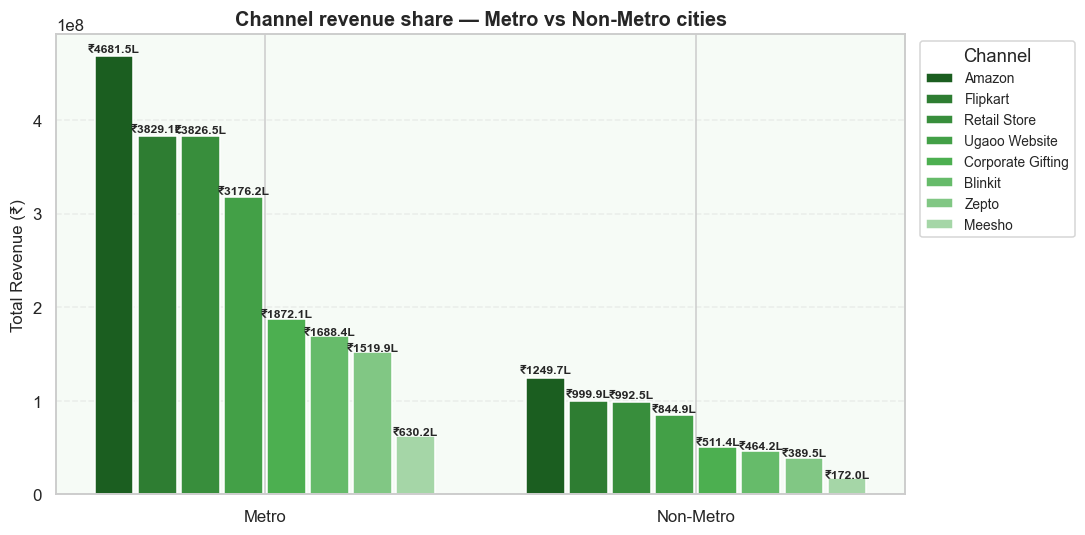

In [47]:
# Channel dominance — Metro vs Non-Metro cities
# Classify top 5 cities as Metro, rest as Non-Metro
_top5_cities = city_ch.groupby(_city_col)[_rev_col].sum().nlargest(5).index.tolist()
city_ch['city_tier'] = city_ch[_city_col].apply(lambda x: 'Metro' if x in _top5_cities else 'Non-Metro')

tier_channel = (
    city_ch.groupby(['city_tier', _ch_col])[_rev_col]
           .sum()
           .reset_index()
           .sort_values(_rev_col, ascending=False)
)

channels = tier_channel[_ch_col].unique()
tiers    = ['Metro', 'Non-Metro']
x = np.arange(len(tiers))
width = 0.8 / max(len(channels), 1)

fig, ax = plt.subplots(figsize=(10, 5))
for i, ch in enumerate(channels):
    sub = tier_channel[tier_channel[_ch_col] == ch].set_index('city_tier')
    vals = [sub.loc[t, _rev_col] if t in sub.index else 0 for t in tiers]
    offset = (i - len(channels)/2 + 0.5) * width
    bars_t = ax.bar(x + offset, vals, width=width*0.9,
                    color=UGAOO_GREEN[i % len(UGAOO_GREEN)], label=ch)
    for bar, val in zip(bars_t, vals):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.01,
                    f'₹{val/1e5:.1f}L', ha='center', fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(tiers, fontsize=11)
ax.set_ylabel('Total Revenue (₹)', fontsize=11)
ax.set_title('Channel revenue share — Metro vs Non-Metro cities', fontsize=13, fontweight='bold')
ax.legend(title='Channel', fontsize=9, bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.set_facecolor(BG_COLOR)
plt.tight_layout(); plt.show()

<div style="background:#f9fbe7;border-left:5px solid #aed581;padding:16px;border-radius:8px;color:#000;">

**City × Channel Insights**

- The top city × channel combinations (visible in the chart above) show where Ugaoo's revenue is actually concentrated — a small number of city-channel pairs drive a disproportionate share of total sales.
- Metro cities generate significantly more revenue than non-metro cities across all channels, confirming that the business is currently metro-dependent.
- The channel mix varies by city tier — use this to decide where to invest in marketplace promotions vs. direct website traffic. Non-metro growth, if targeted, can reduce this geographic concentration risk.
</div>

<div style="display:inline-block;background-color:#e8f5e9;border-radius:9999px;padding:6px 18px;font-size:17px;font-weight:700;color:#111;"> Customer Retention Analysis</div>

### Repeat Purchase Analysis

This section looks at which customers placed more than one order, how repeat rates differ by segment and acquisition channel, and how quickly customers return for a second purchase. These metrics are more useful than raw order counts because they reflect customer loyalty and long-term value — a customer who returns twice is worth more than two one-time buyers.

In [48]:
# Repeat purchase base table
customer_orders = (
    df.groupby('customer_id')
      .agg(
          total_orders=('order_id', 'nunique'),
          total_revenue=('order_value', 'sum'),
          first_order_date=('order_date', 'min'),
          last_order_date=('order_date', 'max'),
          segment=('segment', 'first'),
          acquisition_channel=('acquisition_channel', 'first')
      )
      .reset_index()
)

customer_orders['is_repeat_customer'] = np.where(
    customer_orders['total_orders'] > 1,
    'Repeat',
    'One-time'
)

customer_orders.head()

,customer_id,total_orders,total_revenue,first_order_date,last_order_date,segment,acquisition_channel,is_repeat_customer
0,CUST000001,2,2433.0,2024-01-16,2024-12-03,Returning,Word of Mouth,Repeat
1,CUST000002,3,1877.0,2024-01-23,2025-03-26,Returning,Organic Search,Repeat
2,CUST000003,7,2448.0,2023-06-17,2025-03-19,Returning,Word of Mouth,Repeat
3,CUST000004,9,4603.5,2023-04-23,2024-12-30,Returning,Word of Mouth,Repeat
4,CUST000005,3,949.0,2024-01-29,2024-12-03,New,Organic Search,Repeat


In [49]:
# Repeat vs One-time customer summary
total_customers = customer_orders['customer_id'].nunique()
total_rev       = customer_orders['total_revenue'].sum()

repeat_vs_onetime = (
    customer_orders
    .groupby('is_repeat_customer')
    .agg(
        customers        = ('customer_id',   'nunique'),
        total_revenue    = ('total_revenue', 'sum'),
        avg_revenue_per_customer = ('total_revenue', 'mean'),
        avg_orders_per_customer  = ('total_orders',  'mean')
    )
    .reset_index()
)

repeat_vs_onetime['customer_share_pct'] = (
    repeat_vs_onetime['customers'] / total_customers * 100
).round(1)
repeat_vs_onetime['revenue_share_pct'] = (
    repeat_vs_onetime['total_revenue'] / total_rev * 100
).round(1)
repeat_vs_onetime['avg_revenue_per_customer'] = repeat_vs_onetime['avg_revenue_per_customer'].round(2)
repeat_vs_onetime['avg_orders_per_customer']  = repeat_vs_onetime['avg_orders_per_customer'].round(2)
repeat_vs_onetime['total_revenue']            = repeat_vs_onetime['total_revenue'].round(2)

repeat_vs_onetime

,is_repeat_customer,customers,total_revenue,avg_revenue_per_customer,avg_orders_per_customer,customer_share_pct,revenue_share_pct
0,One-time,754,609094.0,807.82,1.00,6.4,1.6
1,Repeat,11044,37804568.0,3423.09,4.46,93.6,98.4


#### Repeat Rate by Acquisition Channel

A channel that brings fewer customers but with a high repeat rate delivers more lifetime value than a high-volume channel full of one-time buyers. The table below ranks channels by repeat rate, not volume.

In [50]:
# Acquisition channel-wise repeat rate
channel_repeat = (
    customer_orders
    .groupby('acquisition_channel')
    .agg(
        total_customers          = ('customer_id',   'nunique'),
        repeat_customers         = ('is_repeat_customer', lambda x: (x == 'Repeat').sum()),
        total_revenue            = ('total_revenue', 'sum'),
        avg_revenue_per_customer = ('total_revenue', 'mean')
    )
    .reset_index()
)

channel_repeat['repeat_rate_pct'] = (
    channel_repeat['repeat_customers'] / channel_repeat['total_customers'] * 100
).round(1)
channel_repeat['avg_revenue_per_customer'] = channel_repeat['avg_revenue_per_customer'].round(2)
channel_repeat['total_revenue']            = channel_repeat['total_revenue'].round(2)

channel_repeat.sort_values('repeat_rate_pct', ascending=False).reset_index(drop=True)

,acquisition_channel,total_customers,repeat_customers,total_revenue,avg_revenue_per_customer,repeat_rate_pct
0,Word of Mouth,2137,2018,6996527.5,3274.00,94.4
1,Google Ads,1346,1263,4272055.0,3173.89,93.8
2,Instagram,2409,2256,8010551.0,3325.26,93.6
3,Influencer,993,927,3302403.5,3325.68,93.4
4,Organic Search,2567,2398,8218067.0,3201.43,93.4
5,Amazon,1750,1631,5719631.5,3268.36,93.2
6,Email,596,551,1894426.5,3178.57,92.4


#### Repeat Rate by Customer Segment

Segments are evaluated by repeat quality — not just how many orders they place, but how often they return.

In [51]:
# Segment-wise repeat rate
segment_repeat = (
    customer_orders
    .groupby('segment')
    .agg(
        total_customers          = ('customer_id',   'nunique'),
        repeat_customers         = ('is_repeat_customer', lambda x: (x == 'Repeat').sum()),
        total_revenue            = ('total_revenue', 'sum'),
        avg_revenue_per_customer = ('total_revenue', 'mean')
    )
    .reset_index()
)

segment_repeat['repeat_rate_pct'] = (
    segment_repeat['repeat_customers'] / segment_repeat['total_customers'] * 100
).round(1)
segment_repeat['avg_revenue_per_customer'] = segment_repeat['avg_revenue_per_customer'].round(2)
segment_repeat['total_revenue']            = segment_repeat['total_revenue'].round(2)

segment_repeat.sort_values('repeat_rate_pct', ascending=False).reset_index(drop=True)

,segment,total_customers,repeat_customers,total_revenue,avg_revenue_per_customer,repeat_rate_pct
0,Loyal,3167,2971,10410413.5,3287.15,93.8
1,New,4510,4225,14509039.5,3217.08,93.7
2,Returning,4121,3848,13494209.0,3274.50,93.4


#### Days to Second Order

For customers who placed more than one order, this measures how many days passed between their first and second purchase. A shorter gap means a stronger first-order experience. A long gap suggests the customer was satisfied but not engaged enough to return quickly.

In [52]:
# Days to second order — per customer
df_sorted = df.sort_values(['customer_id', 'order_date']).copy()
df_sorted['order_number'] = (
    df_sorted.groupby('customer_id').cumcount() + 1
)

first_orders  = df_sorted[df_sorted['order_number'] == 1][['customer_id', 'order_date']].rename(columns={'order_date': 'first_order_date'})
second_orders = df_sorted[df_sorted['order_number'] == 2][['customer_id', 'order_date']].rename(columns={'order_date': 'second_order_date'})

first_second_orders = first_orders.merge(second_orders, on='customer_id', how='inner')
first_second_orders['days_to_second_order'] = (
    first_second_orders['second_order_date'] - first_second_orders['first_order_date']
).dt.days

# Merge back into customer_orders
customer_orders = customer_orders.merge(
    first_second_orders[['customer_id', 'days_to_second_order']],
    on='customer_id', how='left'
)

print("first_second_orders sample:")
display(first_second_orders.head())
print("\ncustomer_orders with days_to_second_order:")
customer_orders.head()

first_second_orders sample:


,customer_id,first_order_date,second_order_date,days_to_second_order
0,CUST000001,2024-01-16,2024-12-03,322
1,CUST000002,2024-01-23,2024-08-18,208
2,CUST000003,2023-06-17,2024-03-24,281
3,CUST000004,2023-04-23,2023-08-29,128
4,CUST000005,2024-01-29,2024-10-27,272



customer_orders with days_to_second_order:


,customer_id,total_orders,total_revenue,first_order_date,last_order_date,segment,acquisition_channel,is_repeat_customer,days_to_second_order
0,CUST000001,2,2433.0,2024-01-16,2024-12-03,Returning,Word of Mouth,Repeat,322.0
1,CUST000002,3,1877.0,2024-01-23,2025-03-26,Returning,Organic Search,Repeat,208.0
2,CUST000003,7,2448.0,2023-06-17,2025-03-19,Returning,Word of Mouth,Repeat,281.0
3,CUST000004,9,4603.5,2023-04-23,2024-12-30,Returning,Word of Mouth,Repeat,128.0
4,CUST000005,3,949.0,2024-01-29,2024-12-03,New,Organic Search,Repeat,272.0


#### Channel Speed to Second Order

Among repeat customers, this shows which acquisition channel leads to the fastest return purchase. Channels where customers come back sooner are generating stronger initial engagement.

In [53]:
# Channel-wise second order speed (repeat customers only)
repeat_customers_df = customer_orders[customer_orders['is_repeat_customer'] == 'Repeat'].copy()

channel_second_order = (
    repeat_customers_df
    .groupby('acquisition_channel')
    .agg(
        repeat_customers           = ('customer_id', 'nunique'),
        avg_days_to_second_order   = ('days_to_second_order', 'mean'),
        median_days_to_second_order= ('days_to_second_order', 'median')
    )
    .reset_index()
)

channel_second_order['avg_days_to_second_order']    = channel_second_order['avg_days_to_second_order'].round(1)
channel_second_order['median_days_to_second_order'] = channel_second_order['median_days_to_second_order'].round(1)
channel_second_order.sort_values('avg_days_to_second_order').reset_index(drop=True)

,acquisition_channel,repeat_customers,avg_days_to_second_order,median_days_to_second_order
0,Instagram,2256,144.5,105.0
1,Amazon,1631,147.7,108.0
2,Organic Search,2398,148.9,110.0
3,Google Ads,1263,148.9,111.0
4,Influencer,927,149.7,111.0
5,Word of Mouth,2018,153.6,111.0
6,Email,551,155.5,118.0


#### Segment Speed to Second Order

Which customer segments return fastest? This helps target re-activation campaigns — segments with long gaps need earlier nudges (email, offer) to bring them back.

In [54]:
# Segment-wise second order speed (repeat customers only)
segment_second_order = (
    repeat_customers_df
    .groupby('segment')
    .agg(
        repeat_customers           = ('customer_id', 'nunique'),
        avg_days_to_second_order   = ('days_to_second_order', 'mean'),
        median_days_to_second_order= ('days_to_second_order', 'median')
    )
    .reset_index()
)

segment_second_order['avg_days_to_second_order']    = segment_second_order['avg_days_to_second_order'].round(1)
segment_second_order['median_days_to_second_order'] = segment_second_order['median_days_to_second_order'].round(1)
segment_second_order.sort_values('avg_days_to_second_order').reset_index(drop=True)

,segment,repeat_customers,avg_days_to_second_order,median_days_to_second_order
0,Returning,3848,146.6,107.0
1,New,4225,149.1,110.0
2,Loyal,2971,152.3,113.0


In [55]:
# Quick retention insights summary
best_ch    = channel_repeat.sort_values('repeat_rate_pct', ascending=False).iloc[0]
fastest_ch = channel_second_order.sort_values('avg_days_to_second_order').iloc[0]

print(f"Best repeat channel  : {best_ch['acquisition_channel']}  ({best_ch['repeat_rate_pct']}% repeat rate)")
print(f"Fastest 2nd order    : {fastest_ch['acquisition_channel']}  (avg {fastest_ch['avg_days_to_second_order']} days)")

Best repeat channel  : Word of Mouth  (94.4% repeat rate)
Fastest 2nd order    : Instagram  (avg 144.5 days)


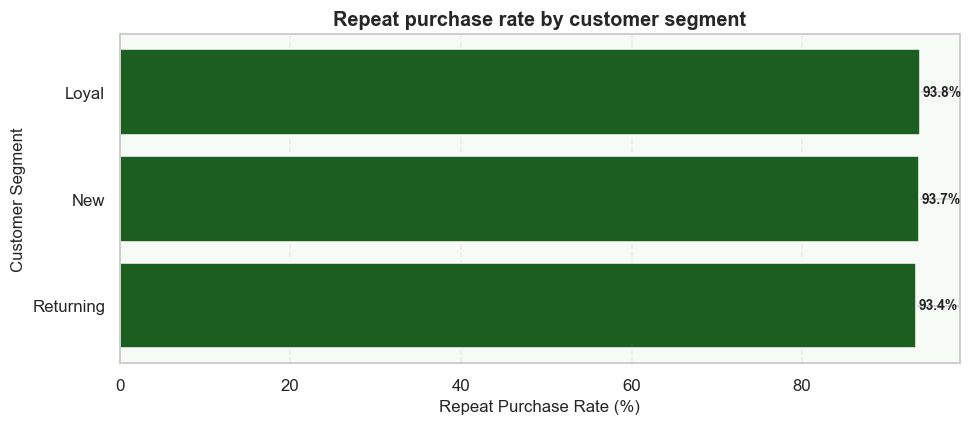

In [56]:
# Chart A — Repeat purchase rate by customer segment
seg_plot = segment_repeat.sort_values('repeat_rate_pct', ascending=True)

plt.figure(figsize=(9, 4))
bars = plt.barh(seg_plot['segment'], seg_plot['repeat_rate_pct'], color=UGAOO_GREEN[0])
for bar, val in zip(bars, seg_plot['repeat_rate_pct']):
    plt.text(val + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')
plt.xlabel('Repeat Purchase Rate (%)', fontsize=11)
plt.ylabel('Customer Segment', fontsize=11)
plt.title('Repeat purchase rate by customer segment', fontsize=13, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.gca().set_facecolor(BG_COLOR)
plt.tight_layout(); plt.show()

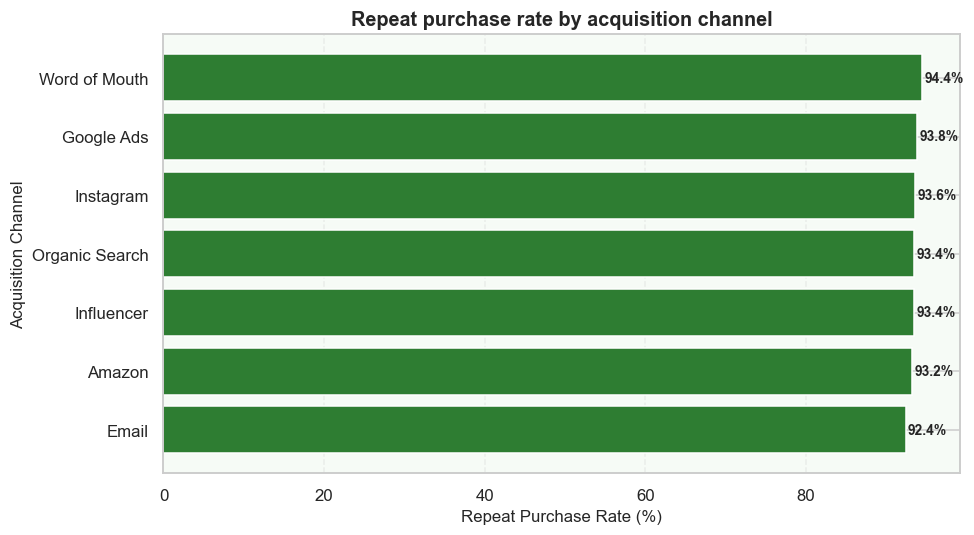

In [57]:
# Chart B — Repeat purchase rate by acquisition channel
ch_plot = channel_repeat.sort_values('repeat_rate_pct', ascending=True)

plt.figure(figsize=(9, 5))
bars = plt.barh(ch_plot['acquisition_channel'], ch_plot['repeat_rate_pct'], color=UGAOO_GREEN[1])
for bar, val in zip(bars, ch_plot['repeat_rate_pct']):
    plt.text(val + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')
plt.xlabel('Repeat Purchase Rate (%)', fontsize=11)
plt.ylabel('Acquisition Channel', fontsize=11)
plt.title('Repeat purchase rate by acquisition channel', fontsize=13, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.gca().set_facecolor(BG_COLOR)
plt.tight_layout(); plt.show()

<div style="background:#e8f5e9;border-left:6px solid #2e7d32;padding:20px;border-radius:8px;color:#000;line-height:1.8;">

### Key Insights

1. **Seeds (category) and Succulents (sub-category)** deliver stronger gross margins than Live Plants despite lower order volumes

2. **Delhi, Mumbai, and Bengaluru** account for the largest share of both orders and profit. Revenue is geographically concentrated — losing traction in any one of these cities would materially impact the business.

3. **COD has a higher return rate than all prepaid payment modes.** This is a direct cost — every COD return means a reverse logistics expense with no revenue retained. Reducing COD share on high-value orders should be a priority.

4. **Discounts above 20% reduce average profit significantly.** High discounts on high-value orders (flagged as risk orders) represent margin leakage without clear volume justification.

5. **Website channel delivers better margin than marketplaces** because there is no platform commission. Every order shifted from Flipkart/Amazon to the website improves unit economics.

6. **Revenue peaks in Oct–Dec** (festive season) and dips in Jun–Aug (monsoon). This seasonality is predictable and should drive inventory and marketing planning.

7. **A small number of city × channel combinations drive most revenue.** Metro cities dominate, and within metros, certain channels are significantly stronger — this concentration creates both efficiency and vulnerability.

8. **Repeat purchase data shows variation by acquisition channel and segment.** Channels that bring customers back faster have higher lifetime value regardless of their acquisition volume.
</div>

<div style="background:#e8f5e9;border-left:6px solid #2e7d32;padding:20px;border-radius:8px;color:#000;line-height:1.8;">

### Business Recommendations

1. **Reduce COD on high-value orders** by offering a small prepaid incentive (e.g. ₹50 cashback or free delivery upgrade). This directly reduces return rate and reverse logistics cost.

2. **Cross-sell Seeds and Succulents alongside Live Plant orders.** These categories have stronger margins — bundling them with high-volume Live Plant purchases improves overall basket margin without changing fulfilment complexity significantly.

3. **Invest in driving traffic to the website** over marketplace channels. Website orders have no commission drag, making them more profitable per rupee of revenue. Loyalty programmes, referral offers, and app-exclusive deals are practical levers.

4. **Cap discounts at 15–20% on high-value orders.** The discount vs profit analysis shows that beyond this threshold, margin erosion is significant. Blanket discounting is less effective than targeted, time-bound promotions.

5. **Build inventory ahead of Oct and Feb** — the two seasonal peaks visible in the revenue trend. Stock shortages in the festive quarter are a direct revenue miss.

6. **Use city × channel analysis to guide channel investment.** Not every channel performs equally in every city — marketplace promotions make more sense in non-metro cities where website organic traffic is lower.

7. **Focus retention campaigns on the channels and segments with the longest days-to-second-order.** These are the customers most at risk of not returning — an early nudge (day 30–45 post first order) via email or push notification can meaningfully improve repeat rate.
</div>